In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(dplyr))
suppressMessages(library(stringr))
suppressMessages(library(ggplot2))
suppressMessages(library(data.table))
suppressMessages(library(sctransform))

In [9]:
obj <- readRDS("cellplex8_soupX.rds")

In [14]:
hvg <- read.csv("cellplex8.bigsur.hvg.csv", row.names = 1)

In [4]:
meta <- read.csv("cellplex8.adata.obs.metadata.csv", row.names=1)
as.data.frame(colnames(meta))

colnames(meta)
<chr>
orig_ident
n_genes
n_genes_by_counts
log1p_n_genes_by_counts
total_counts
log1p_total_counts
pct_counts_in_top_50_genes
pct_counts_in_top_100_genes
pct_counts_in_top_200_genes


In [5]:
meta_to_add <- meta[,c(1,13,16,19,21,24)]
head(meta_to_add)

,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACGAATCCATAGGT-1,basal_mut,3.981288,17.22902,0,0,Basal
AAACGCTAGCGGGTTA-1,basal_mut,3.518228,17.51274,0,0,Basal
AAAGAACAGTTCCGGC-1,basal_mut,3.314334,34.48385,0,0,Basal
AAAGGGCAGAAGTCAT-1,basal_mut,3.316364,31.62909,0,0,Basal
AAAGGGCGTACCAGAG-1,basal_mut,2.783918,33.03399,0,0,Basal
AAAGTGAAGTGGTTAA-1,basal_mut,3.101682,27.30066,0,0,Basal


In [10]:
obj <- AddMetaData(obj, meta_to_add)
head(obj[[]])

,orig.ident,nCount_RNA,nFeature_RNA,orig_ident,pct_counts_mt,pct_counts_ribo,pct_counts_hb,leiden_res_0.10,cell_type
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>
AAACGAATCCATAGGT-1,SeuratProject,9955.828,3107,basal_mut,3.981288,17.22902,0,0,Basal
AAACGCTAGCGGGTTA-1,SeuratProject,10109.623,3198,basal_mut,3.518228,17.51274,0,0,Basal
AAAGAACAGTTCCGGC-1,SeuratProject,9393.055,2541,basal_mut,3.314334,34.48385,0,0,Basal
AAAGGGCAGAAGTCAT-1,SeuratProject,13609.892,3595,basal_mut,3.316364,31.62909,0,0,Basal
AAAGGGCGTACCAGAG-1,SeuratProject,14335.474,3154,basal_mut,2.783918,33.03399,0,0,Basal
AAAGTGAAGTGGTTAA-1,SeuratProject,6779.421,2187,basal_mut,3.101682,27.30066,0,0,Basal


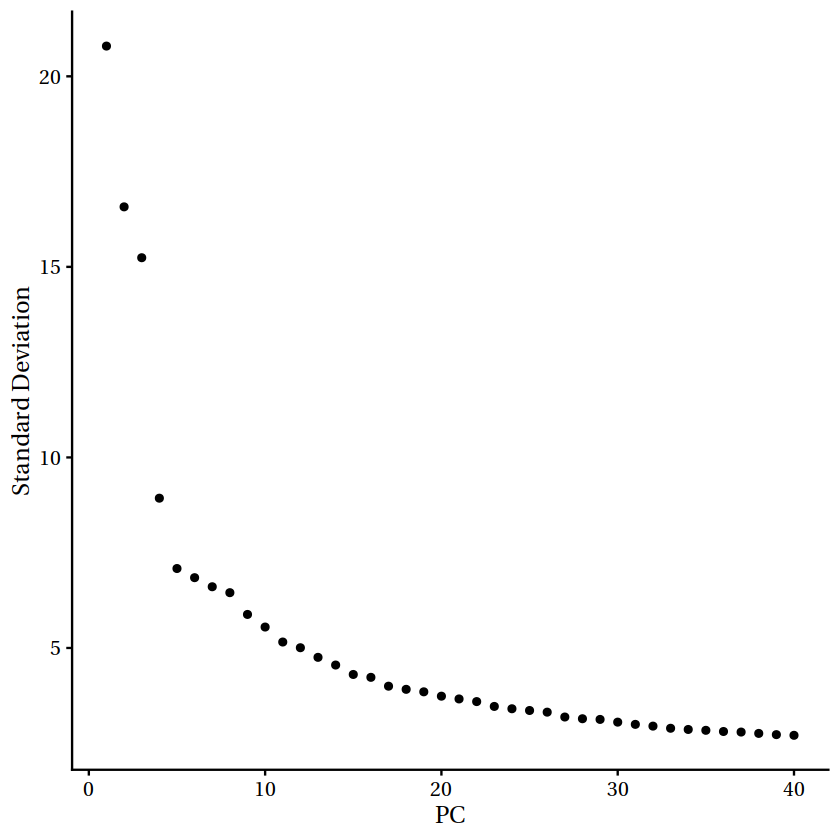

In [11]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_counts_hb.”


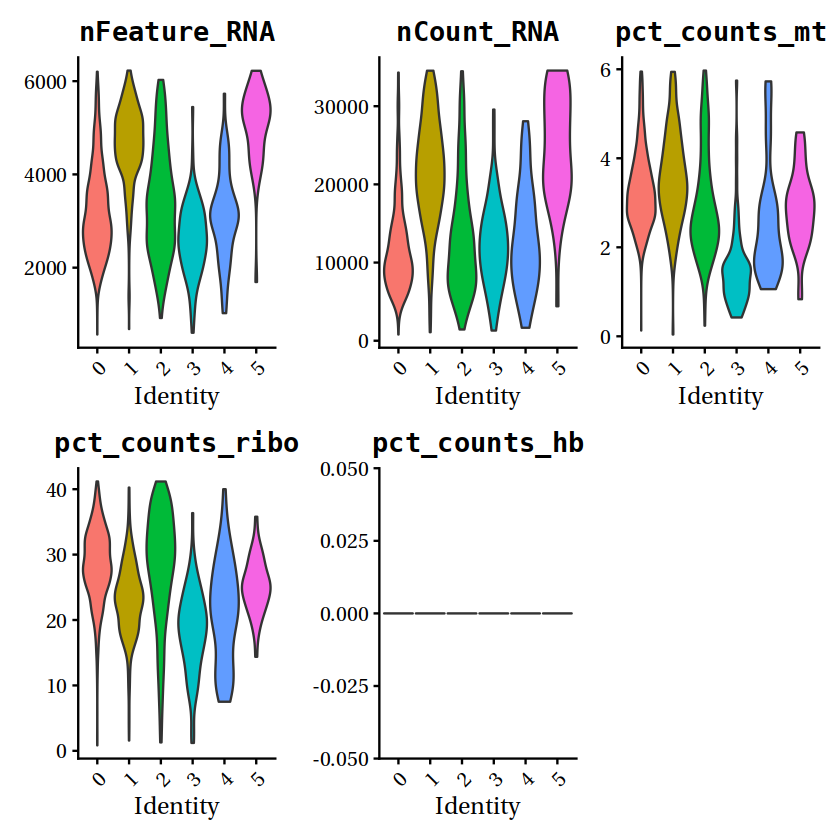

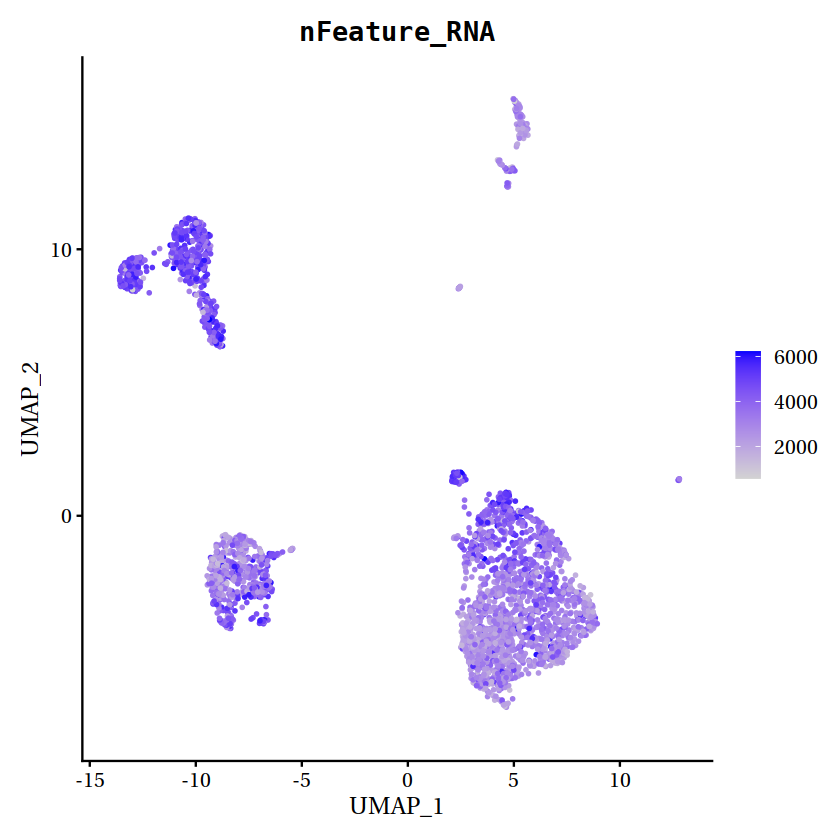

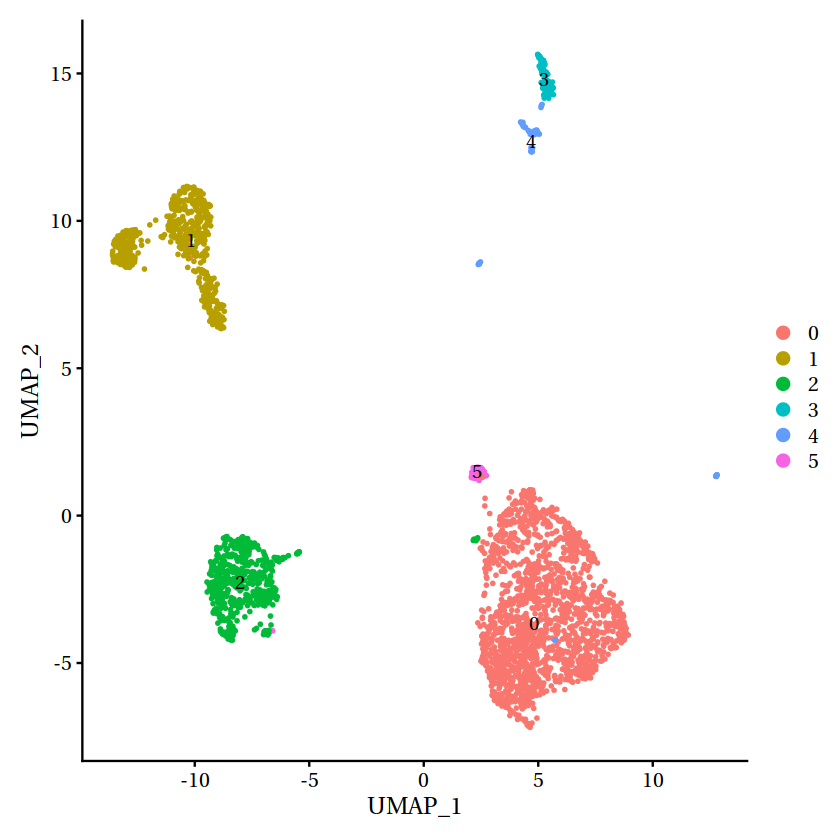

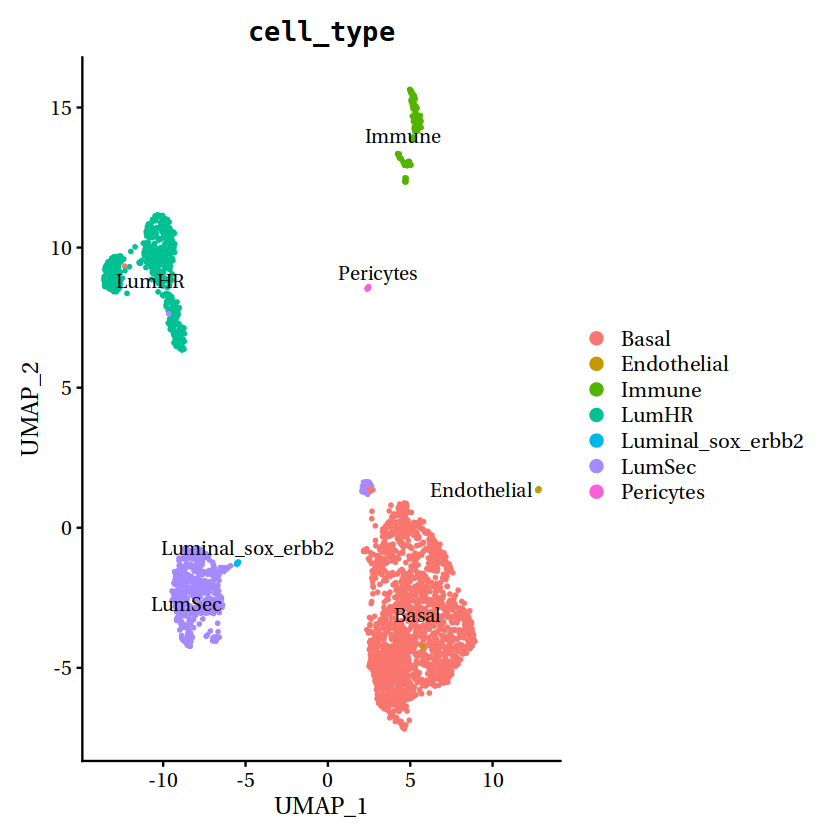

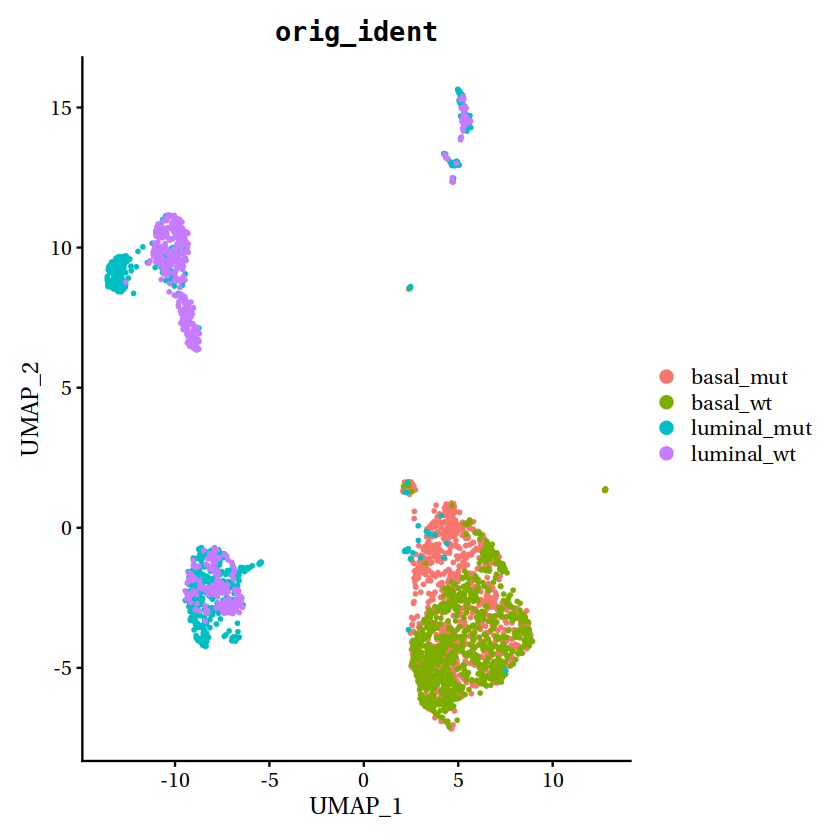

In [12]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.1, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F, repel = T)

In [18]:
Idents(obj) <- "seurat_clusters"

obj <- subset(obj, subset = nFeature_RNA < 750, WhichCells(obj, ident = 0), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 3000, WhichCells(obj, ident = 5), invert = TRUE)
obj <- subset(obj, subset = nFeature_RNA < 2250, WhichCells(obj, ident = 1), invert = TRUE)

obj <- subset(obj, subset = nFeature_RNA > 4500, WhichCells(obj, ident = 3), invert = TRUE)

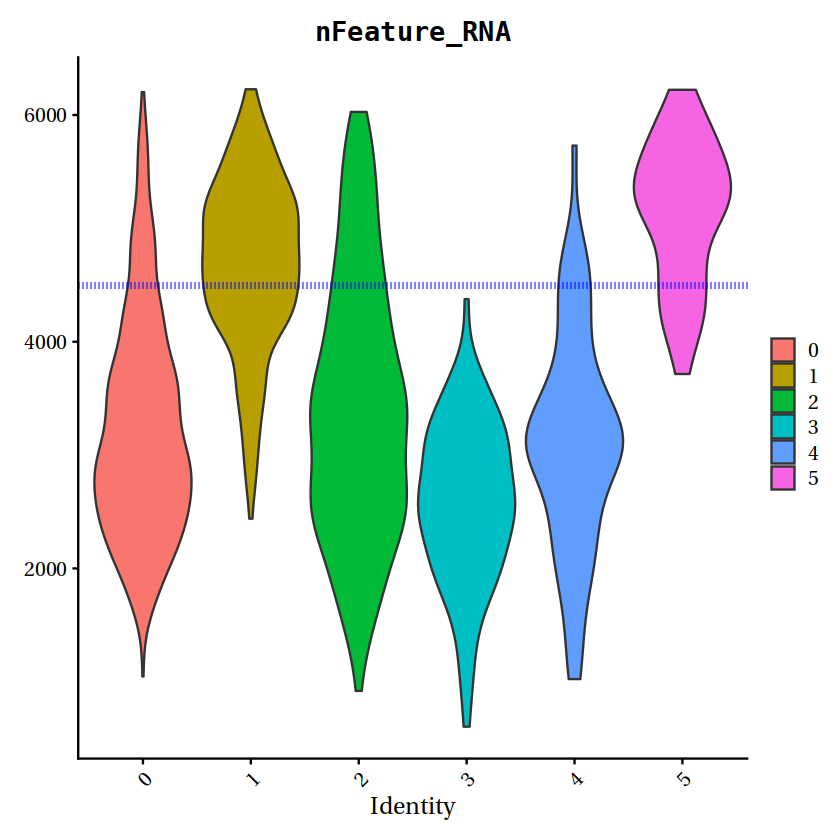

In [19]:
VlnPlot(obj, features = c("nFeature_RNA"), pt.size=0)+ geom_hline(yintercept = 4500, linetype="dotted", 
                color = "blue", size=1.5)

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_counts_hb.”


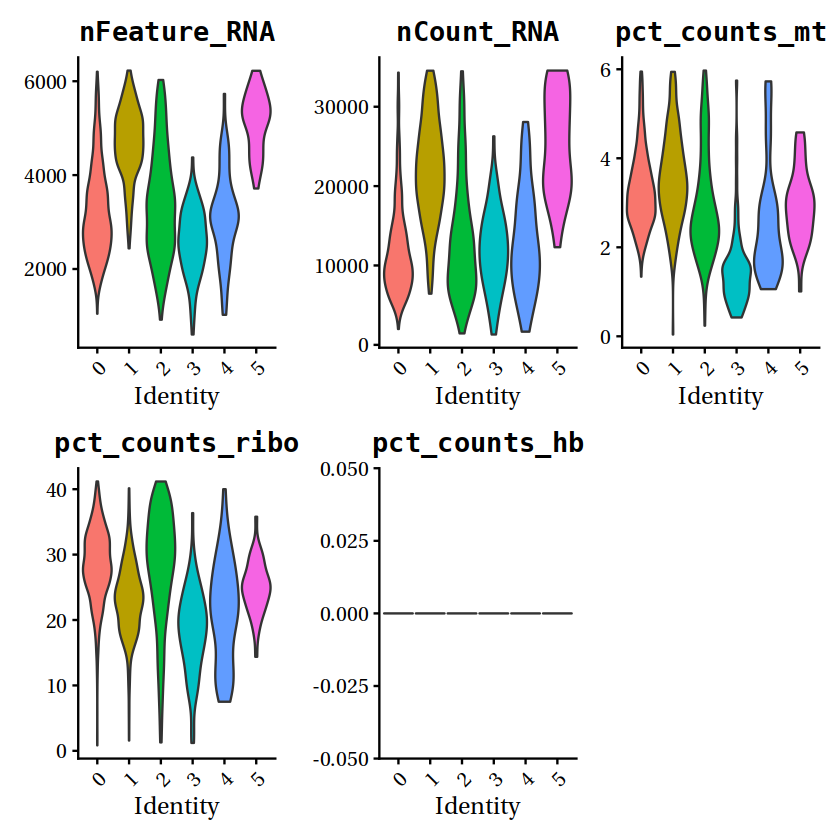

In [20]:
VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)

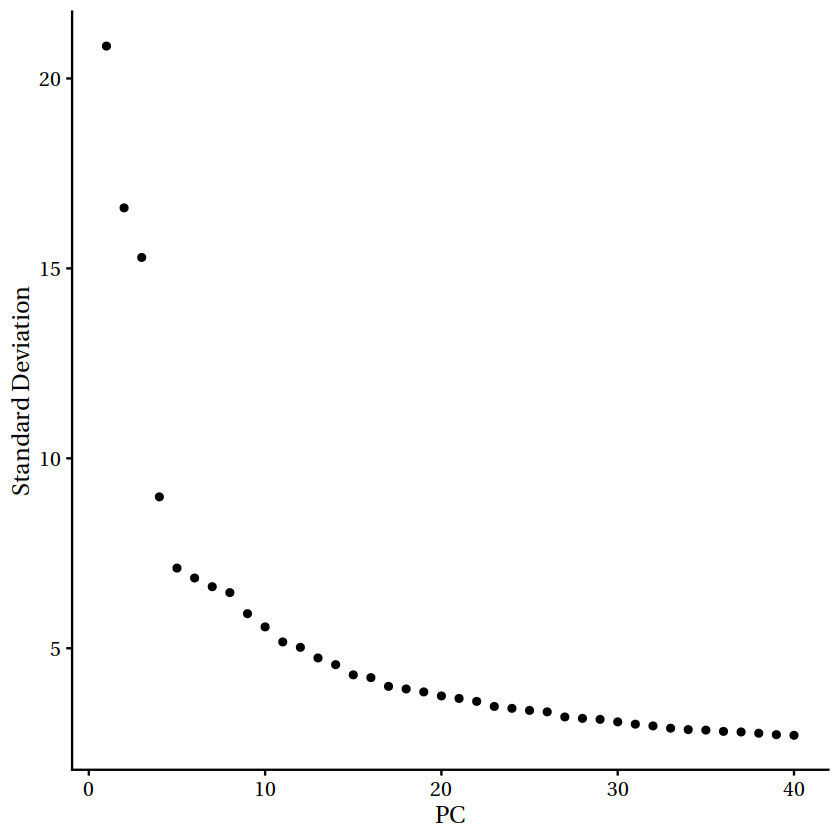

In [21]:
obj <- SCTransform(obj, residual.features = rownames(hvg), verbose = F)
obj <- RunPCA(obj, verbose = F)
ElbowPlot(obj, ndims = 40)

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_counts_hb.”


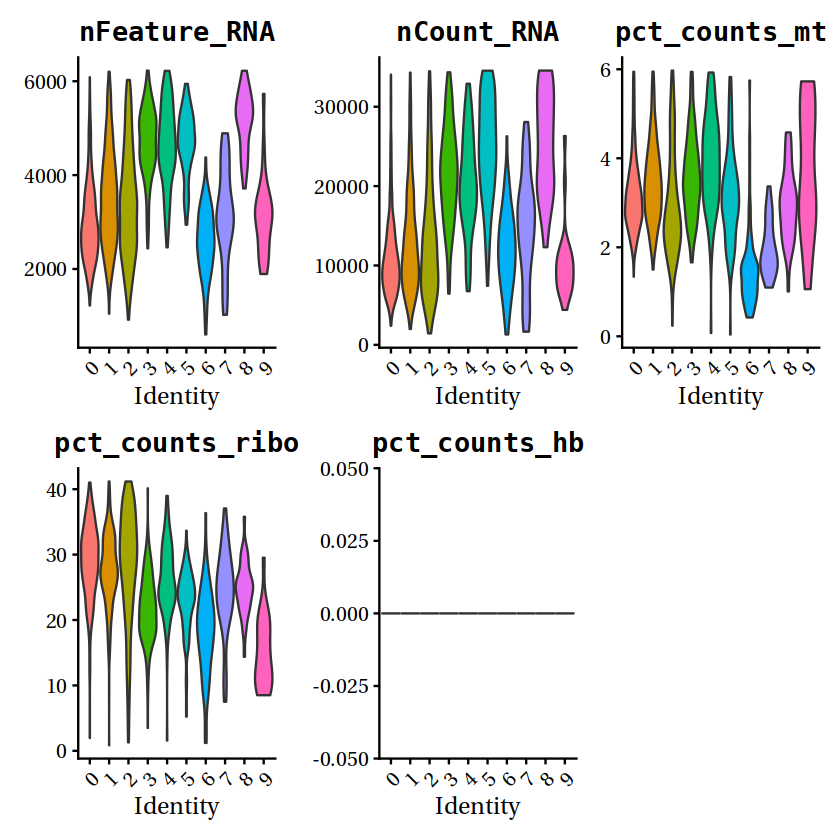

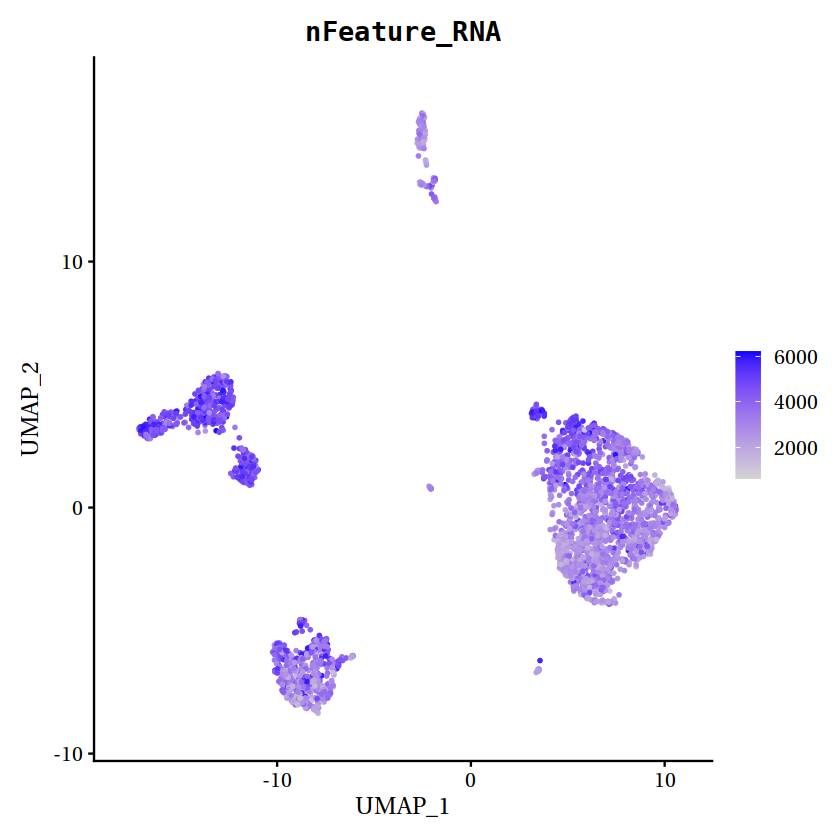

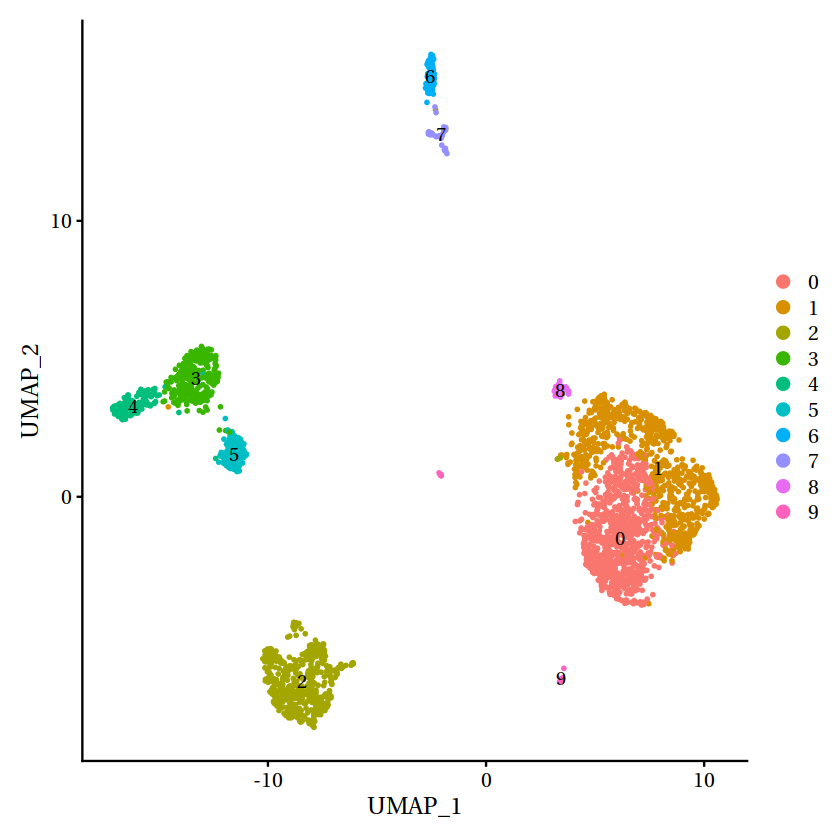

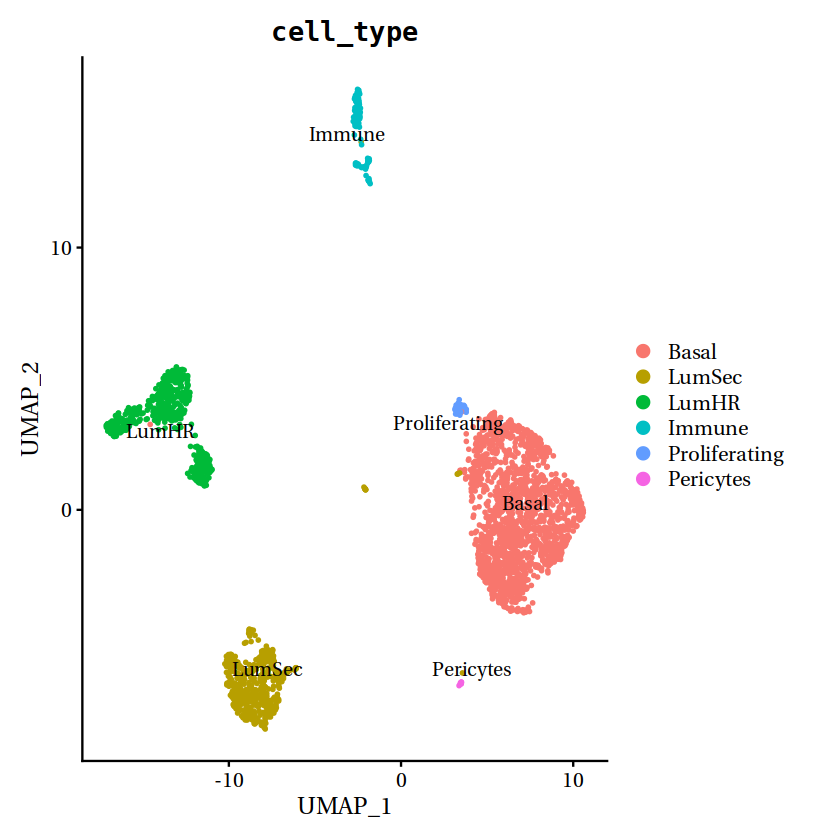

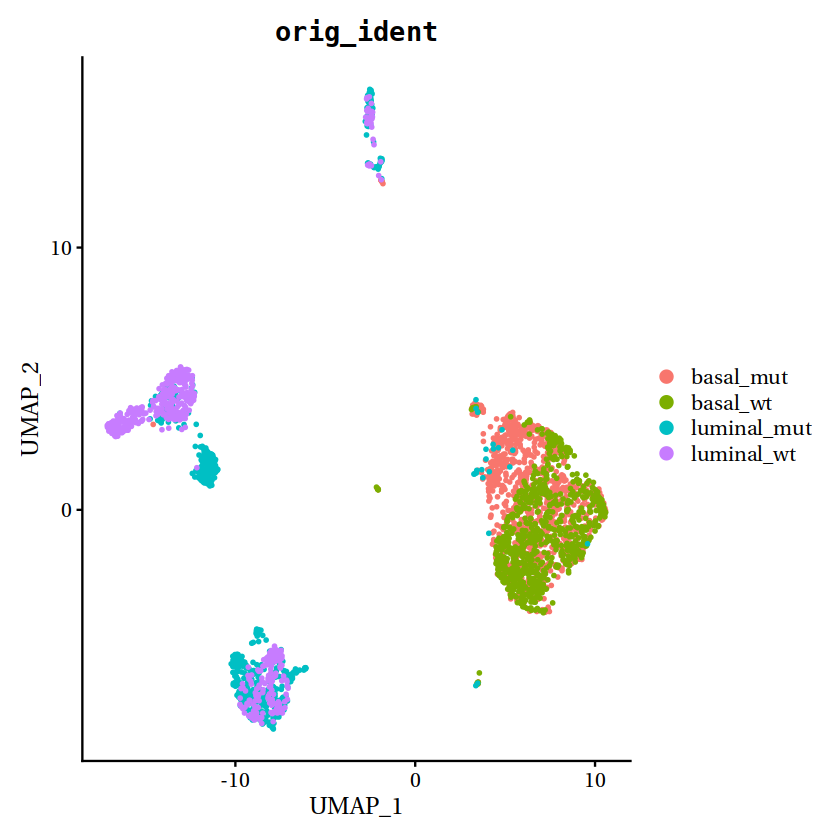

In [42]:
obj <- RunUMAP(obj, reduction = "pca", dims = 1:40, verbose = FALSE)
obj <- FindNeighbors(obj, reduction = "pca", dims = 1:40, verbose = FALSE) 
obj <- FindClusters(obj, resolution = 0.3, verbose = FALSE) 

VlnPlot(obj, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(obj, features=c("nFeature_RNA"))
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)
DimPlot(obj, group.by = "orig_ident", label = F)

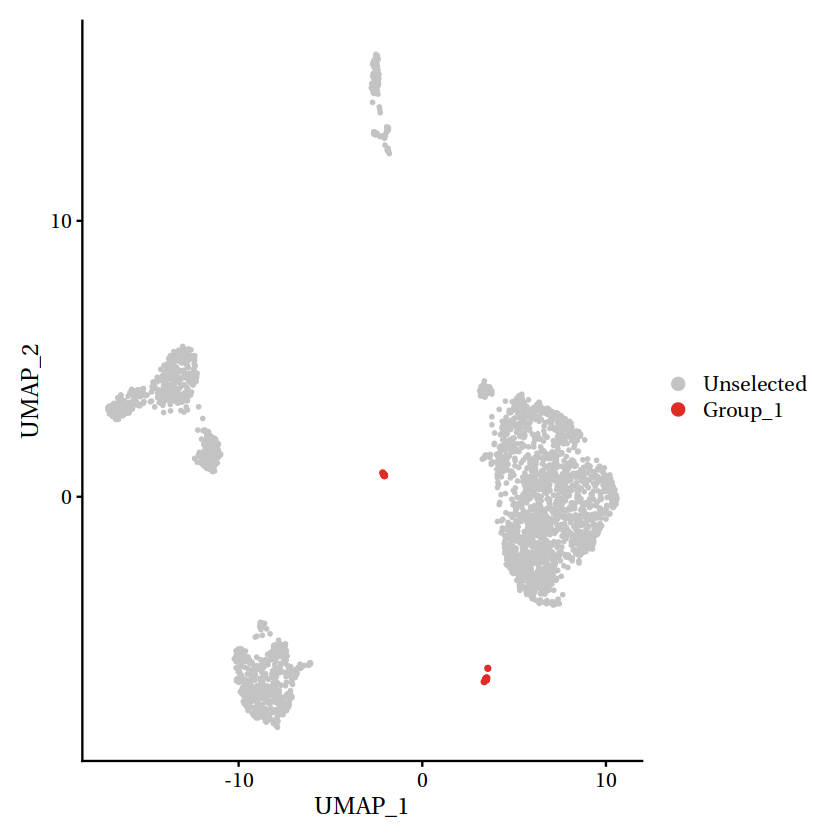

In [43]:
Idents(obj) <- "seurat_clusters"
DimPlot(obj, cells.highlight = WhichCells(obj, ident = c(9)))


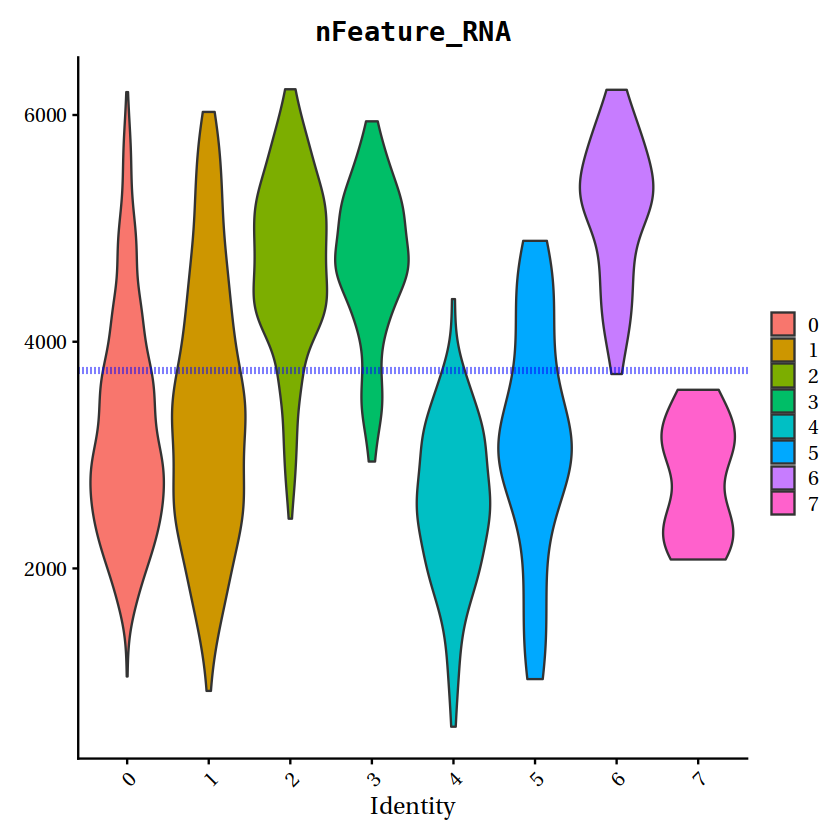

In [23]:
VlnPlot(obj, features = c("nFeature_RNA"), pt.size=0)+ geom_hline(yintercept = 3750, linetype="dotted", 
                color = "blue", size=1.5)

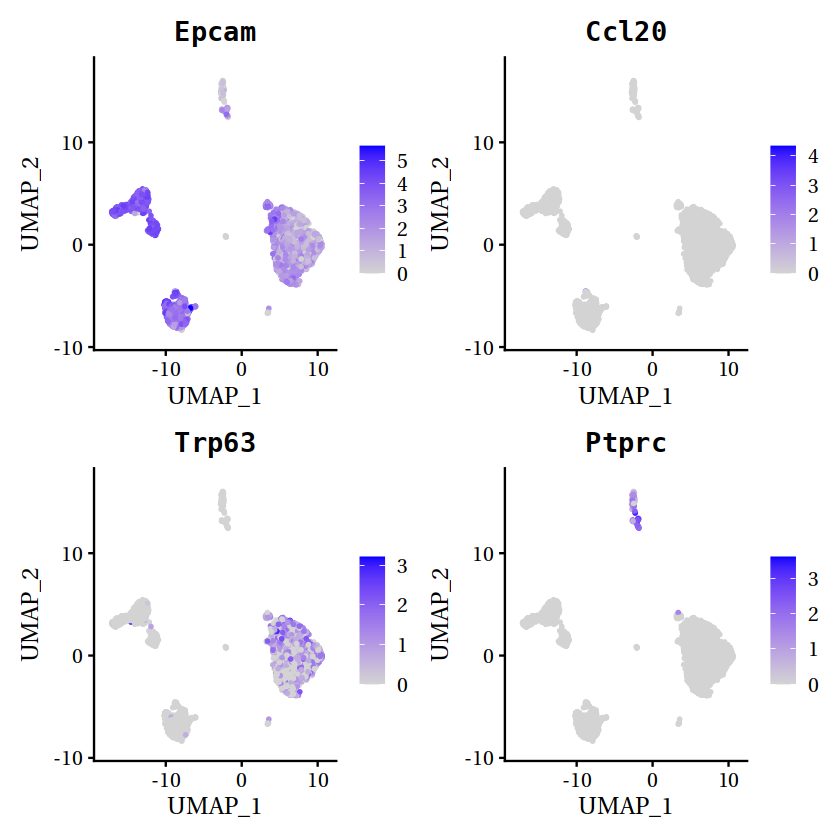

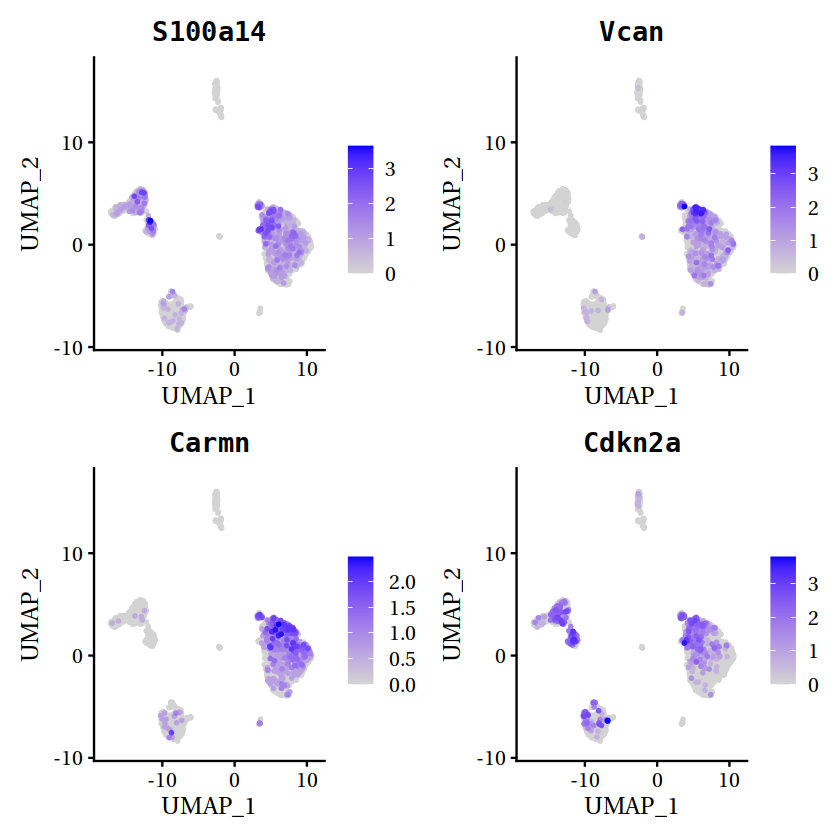

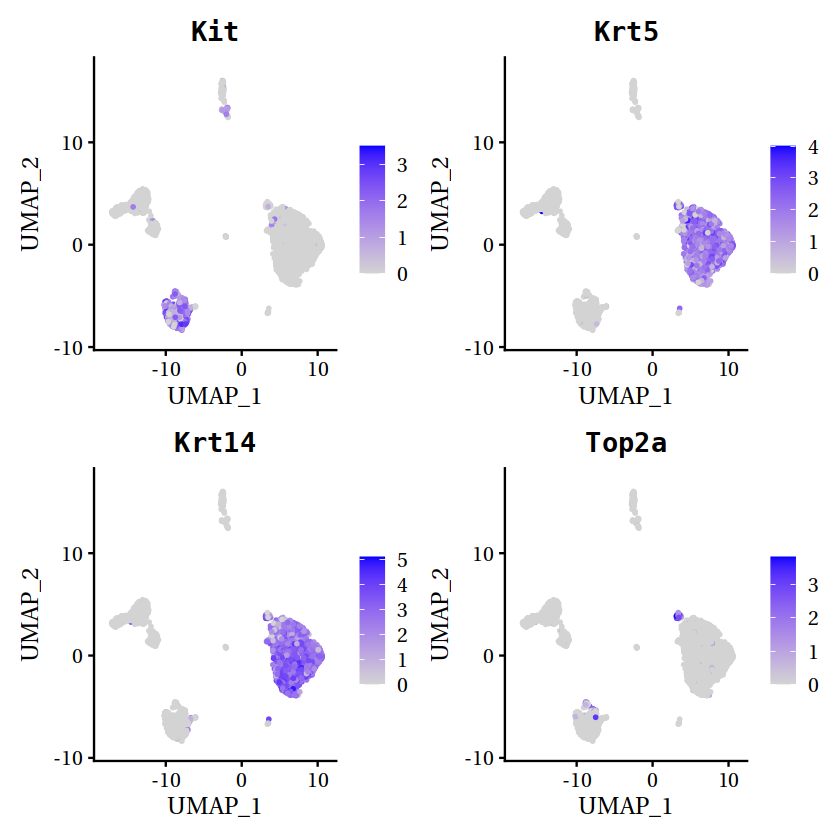

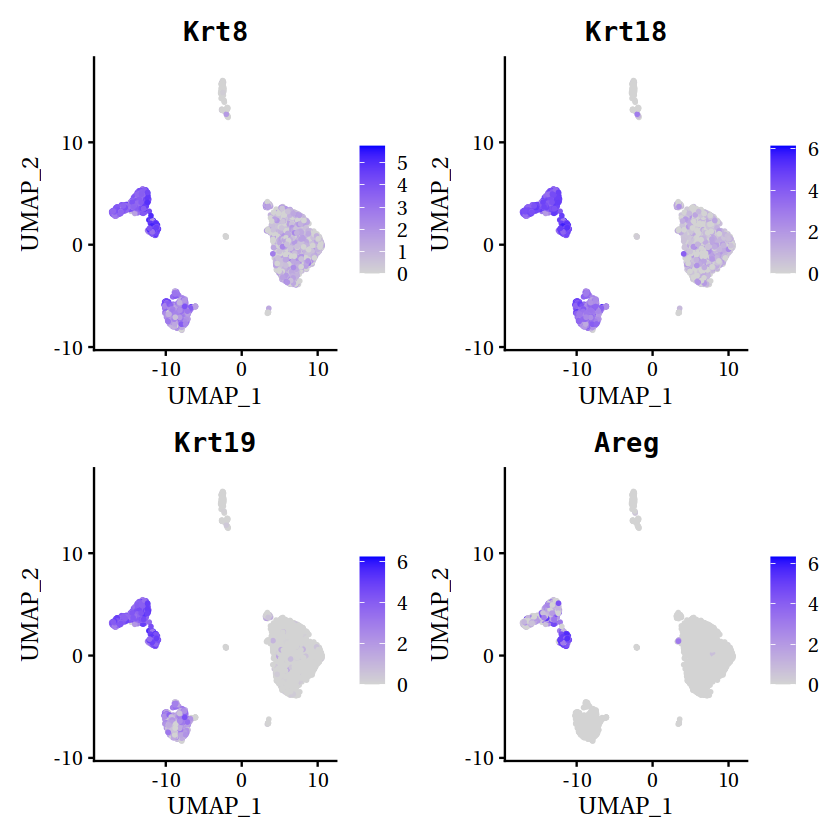

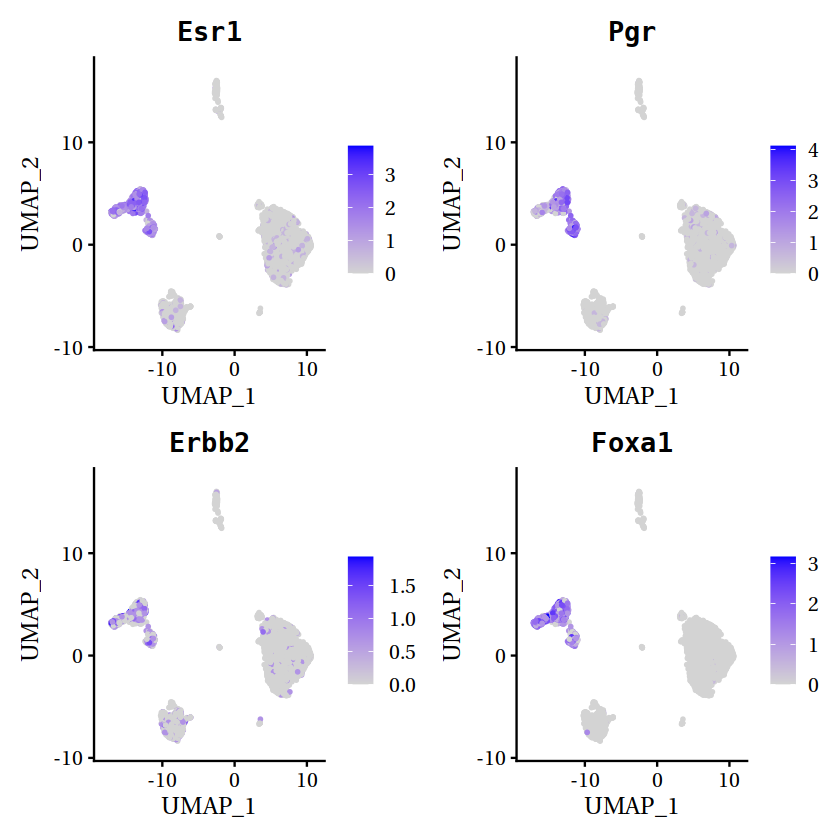

In [24]:
FeaturePlot(obj, c("Epcam","Ccl20","Trp63","Ptprc"))
FeaturePlot(obj, c("S100a14","Vcan","Carmn","Cdkn2a"),order=T)
FeaturePlot(obj, c("Kit","Krt5","Krt14","Top2a"))
FeaturePlot(obj, c("Krt8","Krt18","Krt19","Areg"))
FeaturePlot(obj, c("Esr1","Pgr","Erbb2","Foxa1"))

In [25]:
saveRDS(obj, "cellplex8_soupX.rds")

# after doublet prediction, CNV

In [2]:
obj <- readRDS("cellplex8_soupX_doubletfinder.rds")

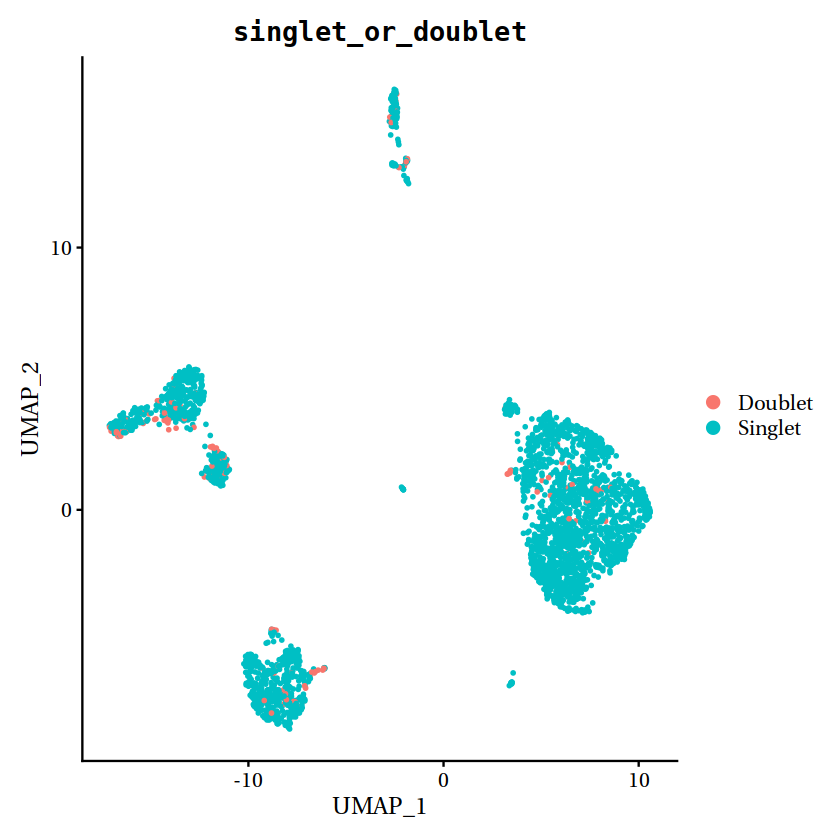

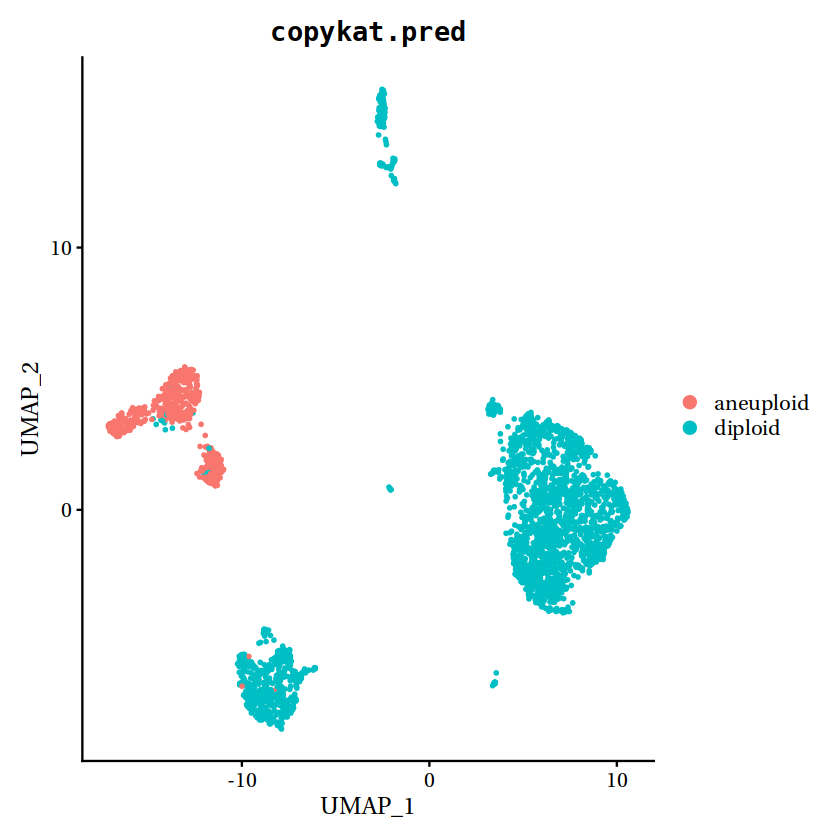

In [3]:
pred <- read.csv("cellplex_8_copykat_prediction.txt", sep = '\t')
rownames(pred) <- pred$cell.names
pred$cell.names <- NULL
obj <- AddMetaData(obj,pred)

DimPlot(obj, group.by="singlet_or_doublet")
DimPlot(obj, group.by="copykat.pred")

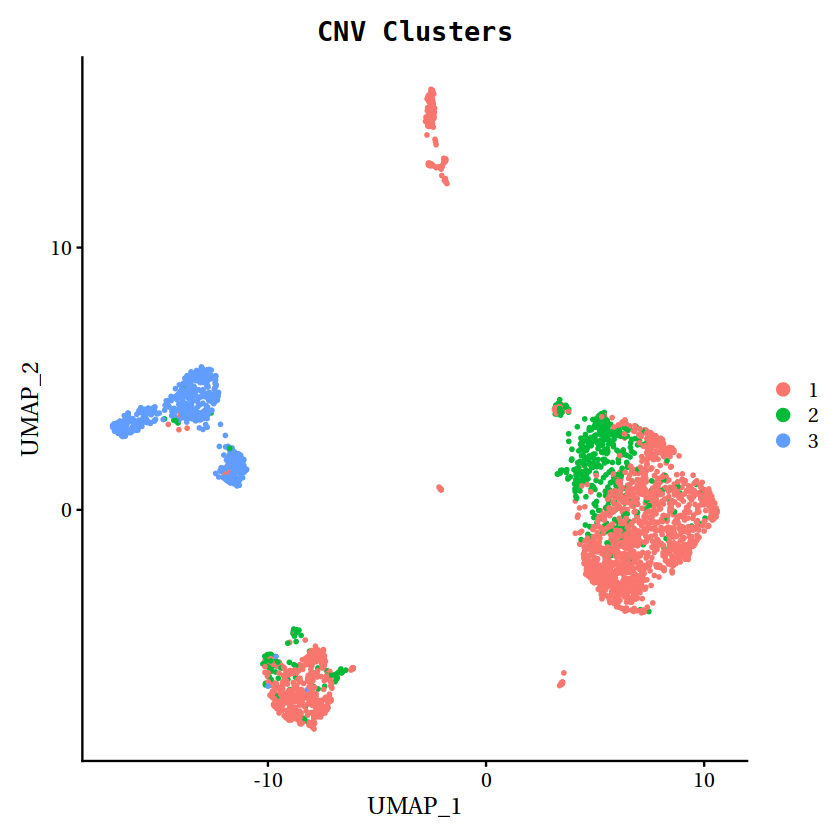

In [7]:
clust_res <- readRDS("cellplex_8_copykat_clustering_results.rds")

x <- cutree(clust_res, k = 3, h = NULL) #after seweing the heatmap
obj <- AddMetaData(obj, x, "hcluster")

DimPlot(obj, group.by = "hcluster", label =F) + ggtitle("CNV Clusters")

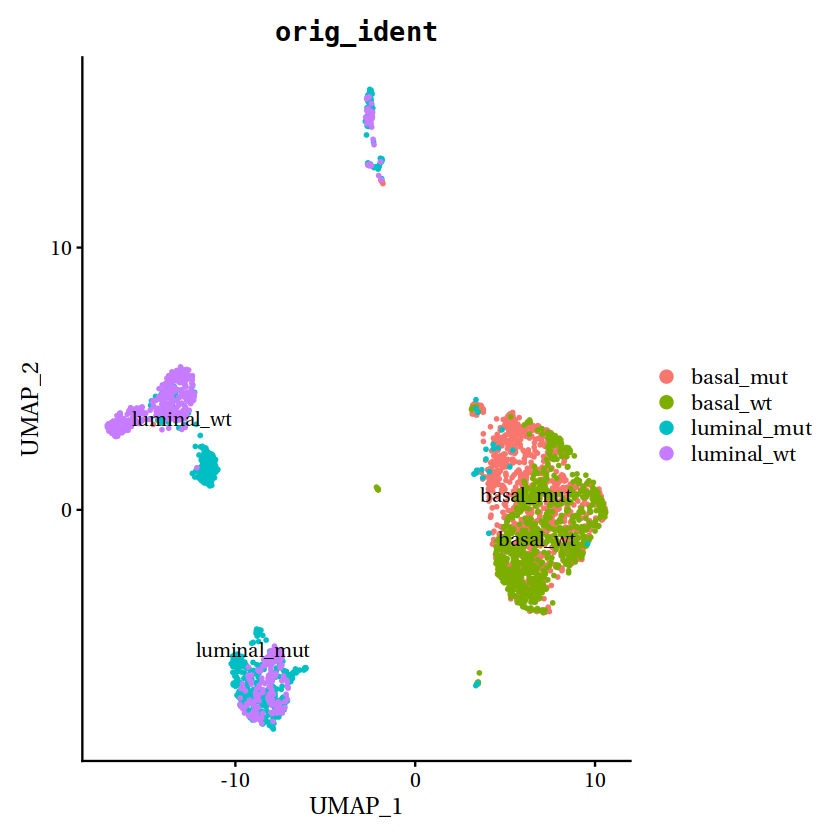

In [8]:
DimPlot(obj, group.by="orig_ident", label = T)

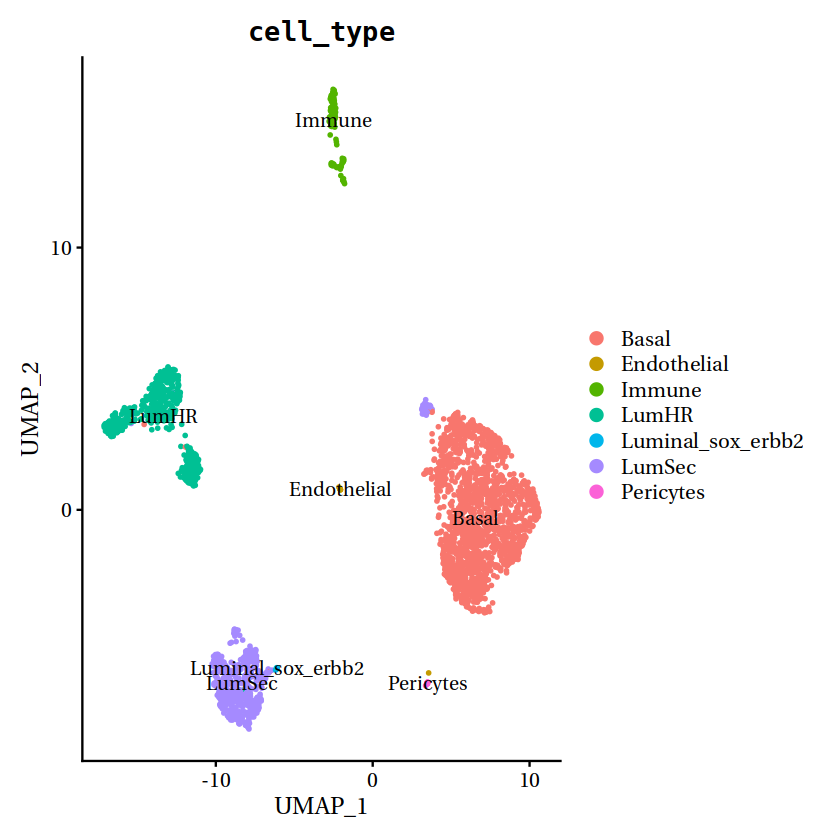

In [9]:
DimPlot(obj, group.by="cell_type", label = T)

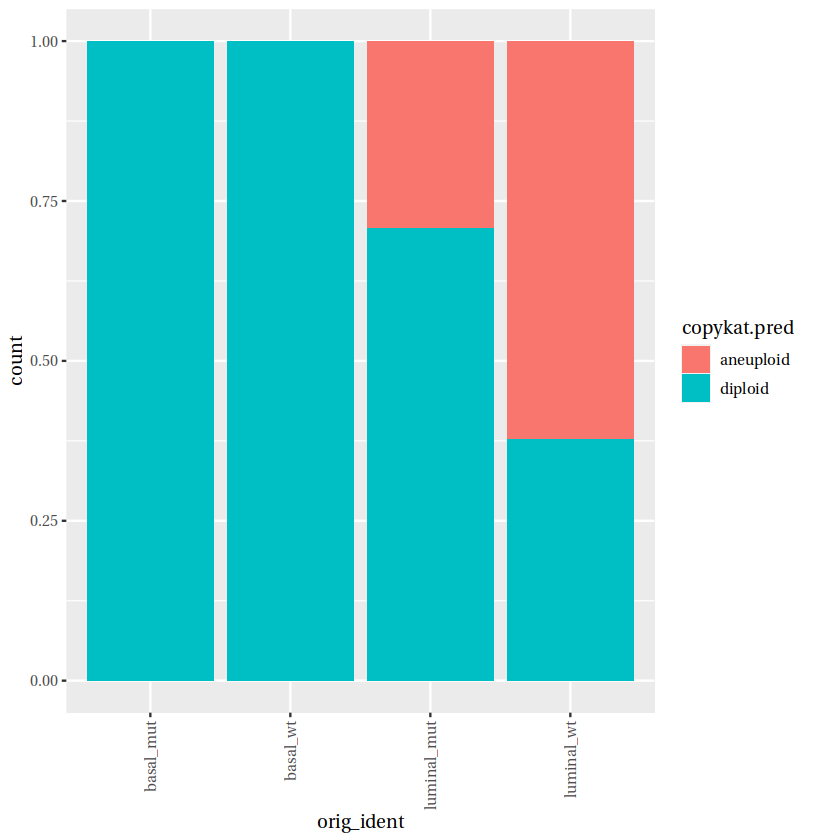

In [10]:
ggplot(obj@meta.data, aes(x=orig_ident, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

### check wt

In [11]:
table(obj$orig_ident)


  basal_mut    basal_wt luminal_mut  luminal_wt 
        932         798         602         539 

In [12]:
sub <- subset(obj, subset = orig_ident %in% c("basal_wt","luminal_wt"))

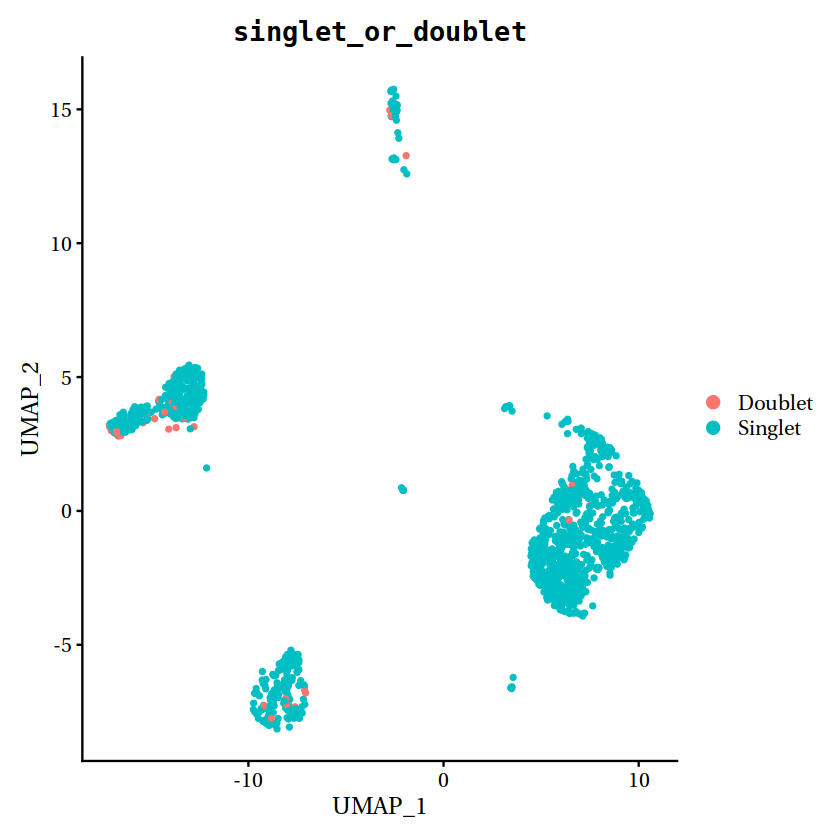

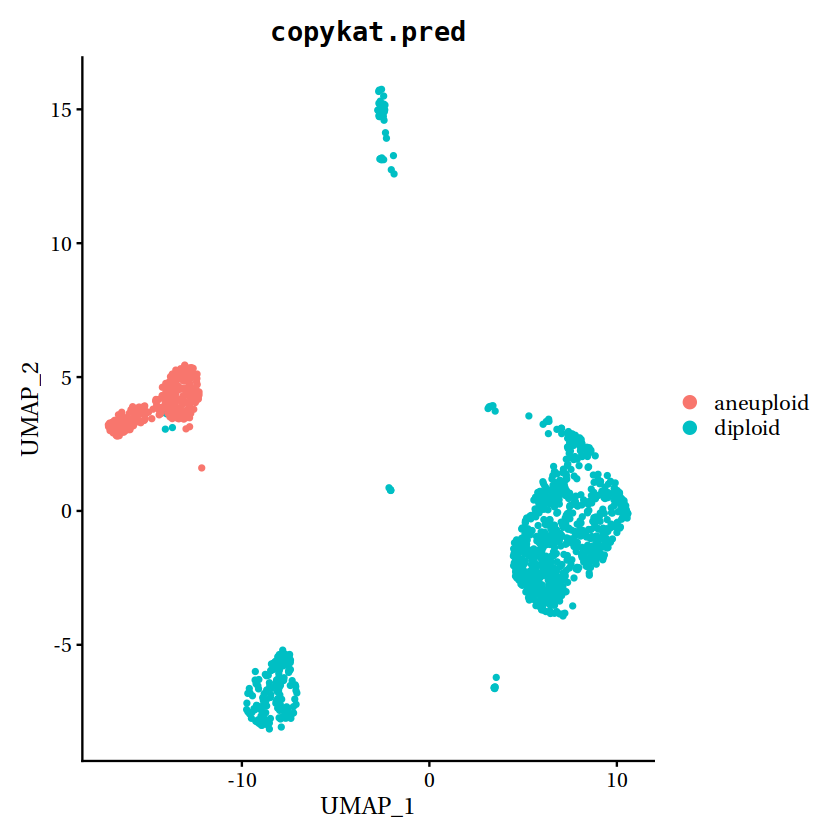

In [13]:
DimPlot(sub, group.by = "singlet_or_doublet")
DimPlot(sub, group.by="copykat.pred")

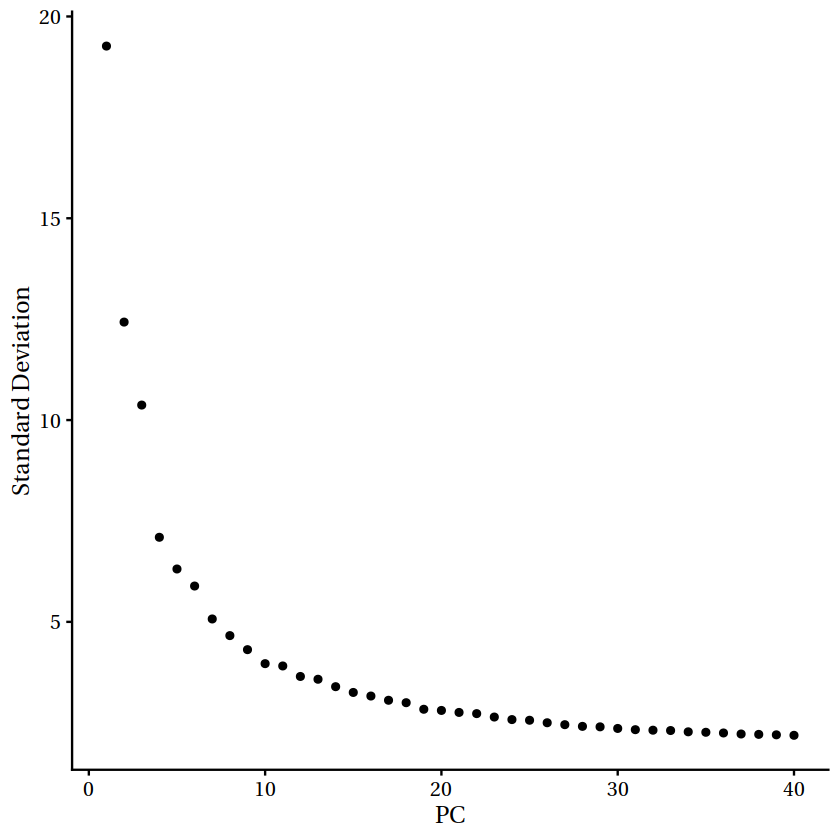

In [16]:
sub <- SCTransform(sub, residual.features = rownames(hvg), verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_counts_hb.”


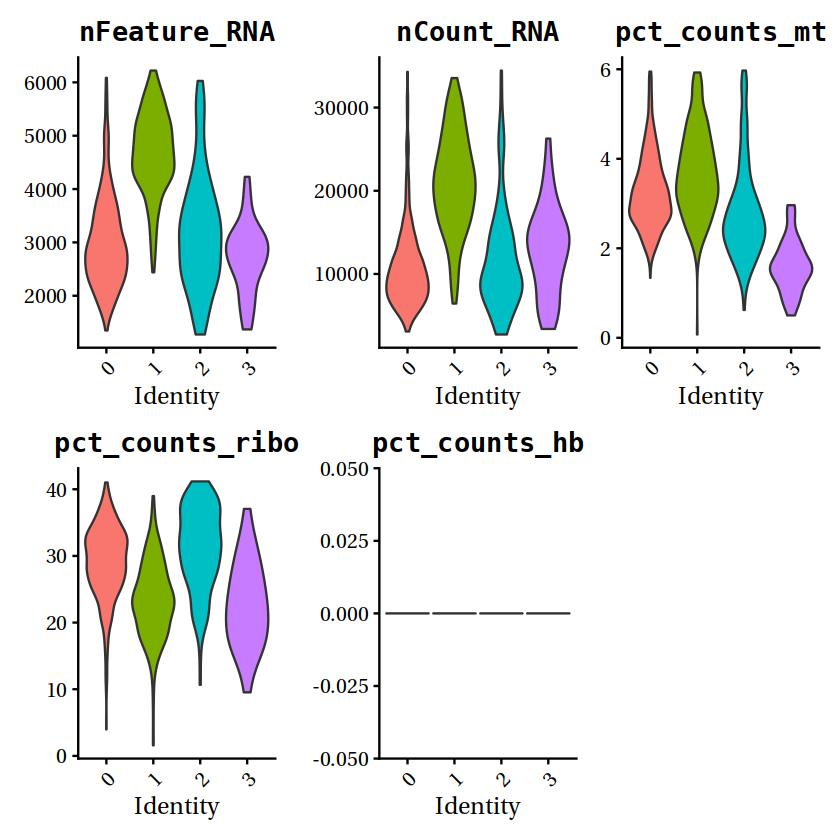

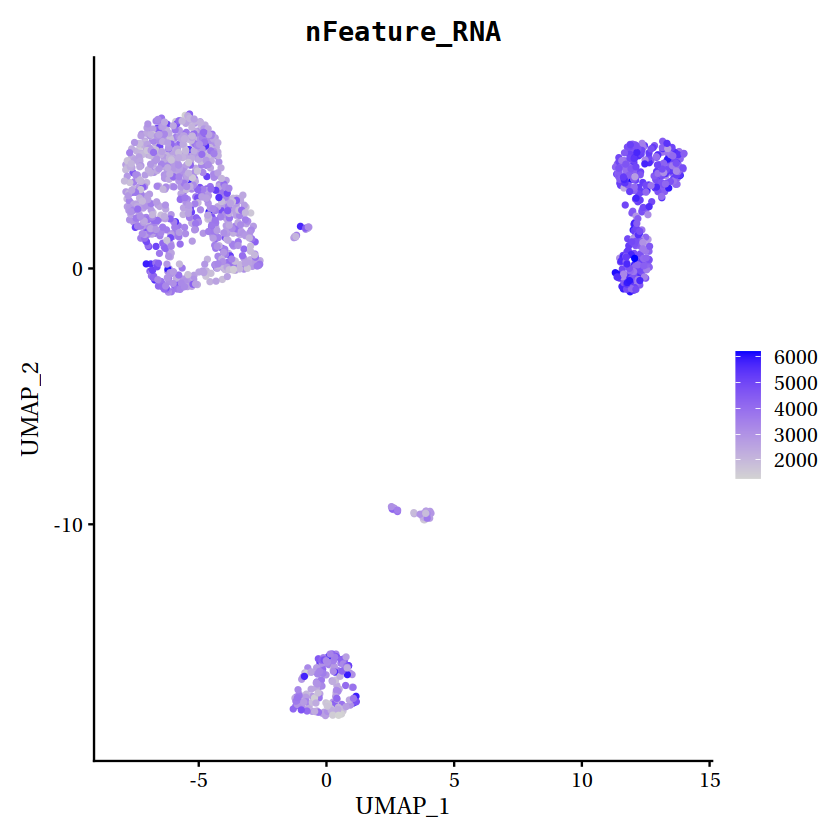

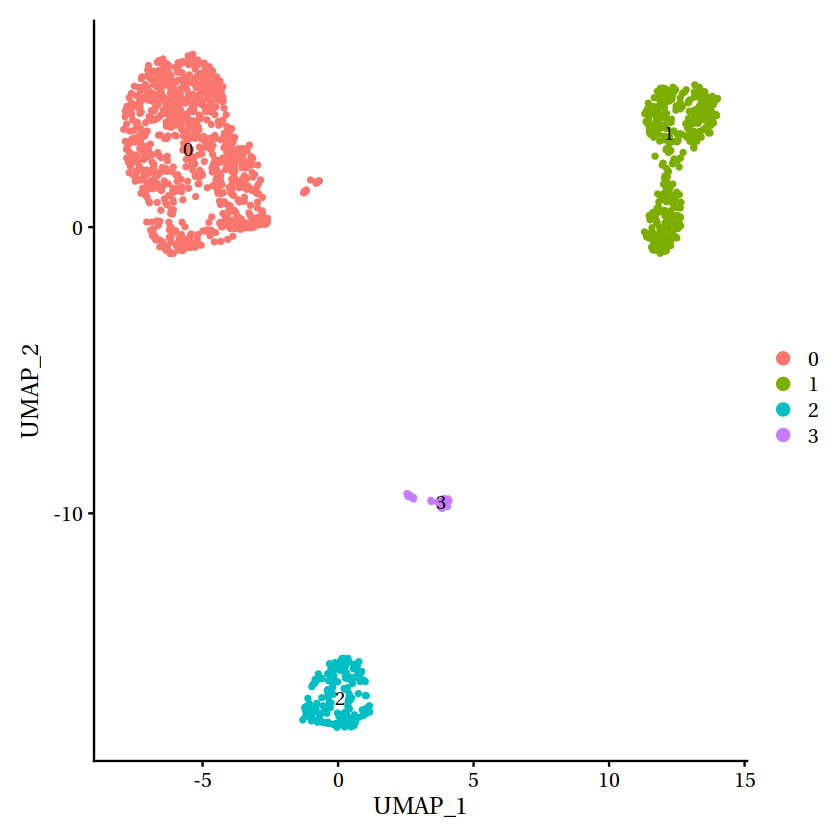

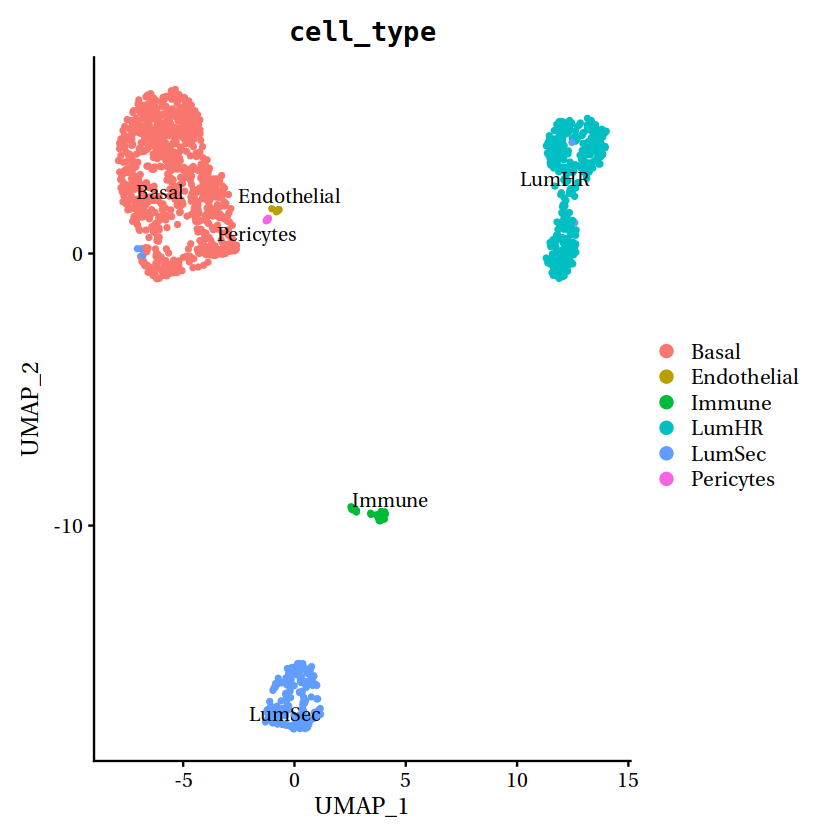

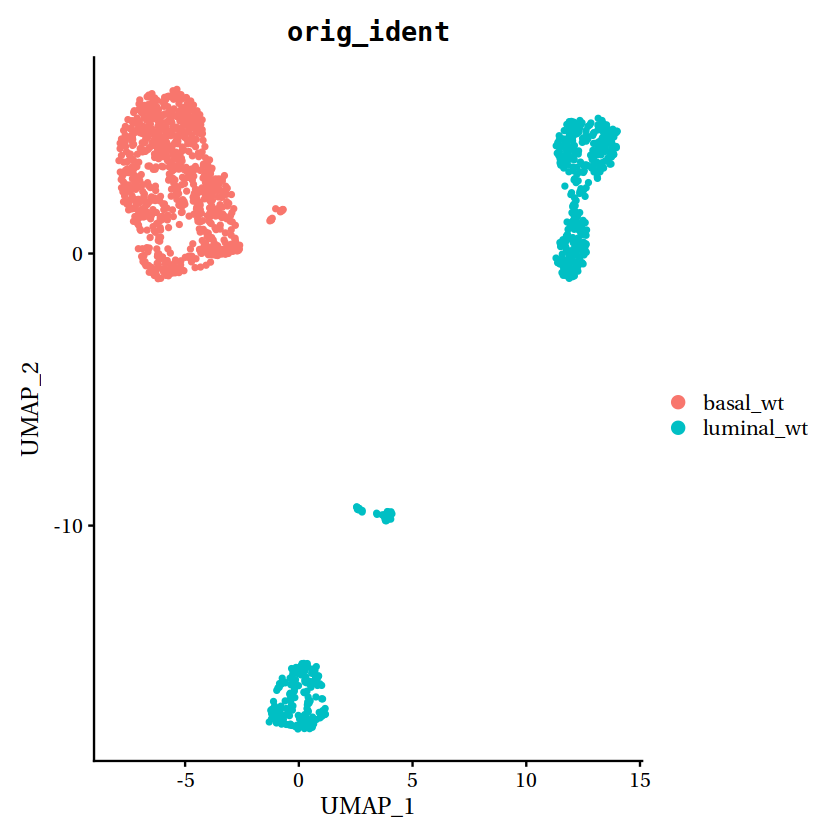

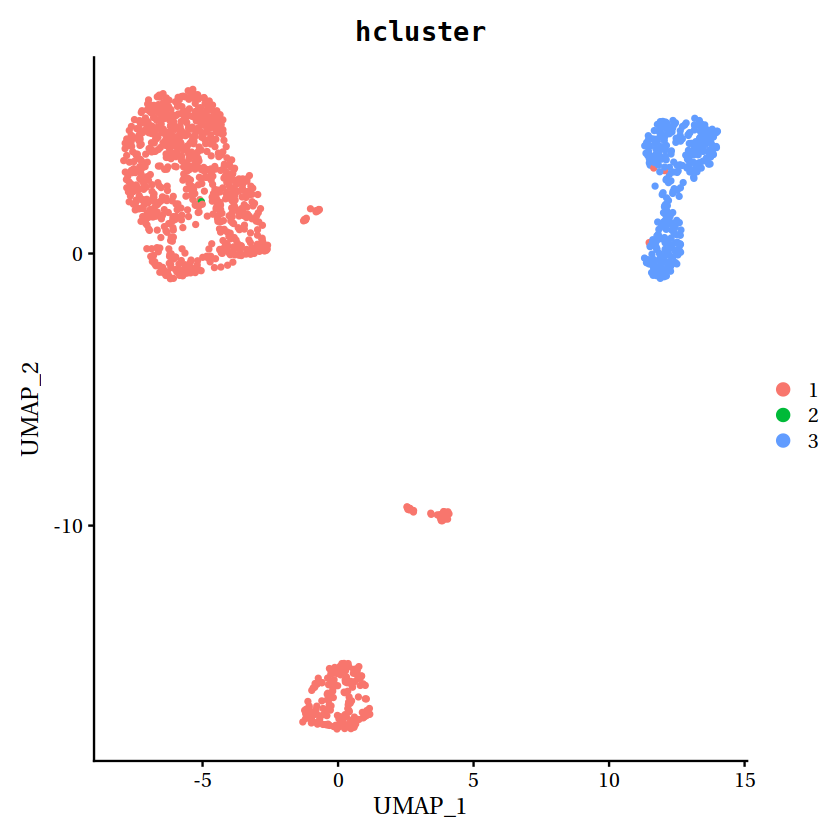

In [17]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "hcluster", label = F)

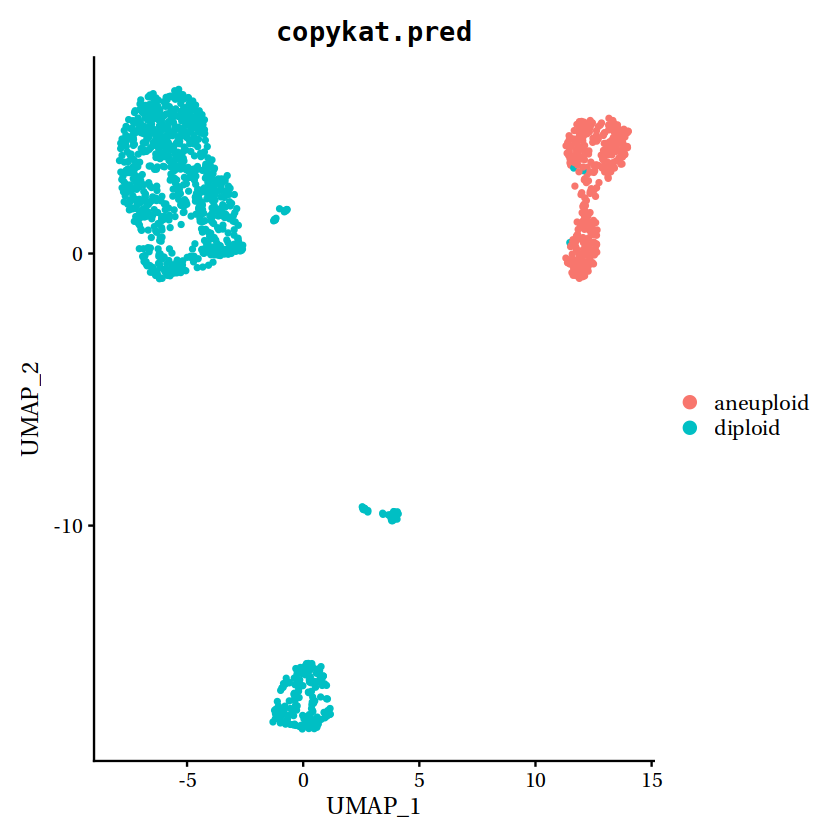

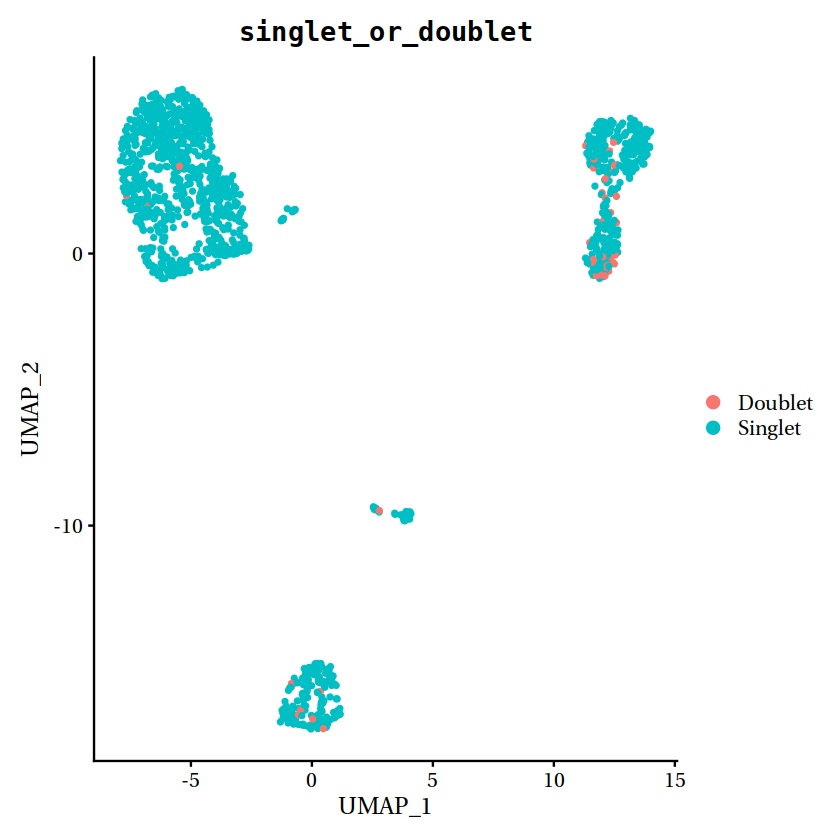

In [19]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="singlet_or_doublet")

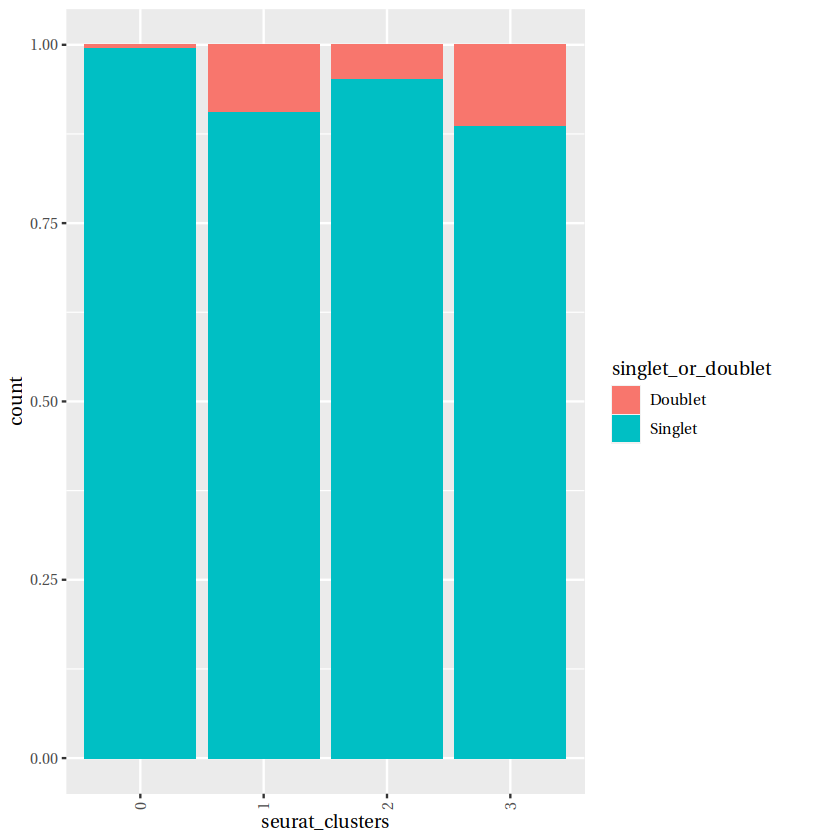

In [20]:
ggplot(sub@meta.data, aes(x=seurat_clusters, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

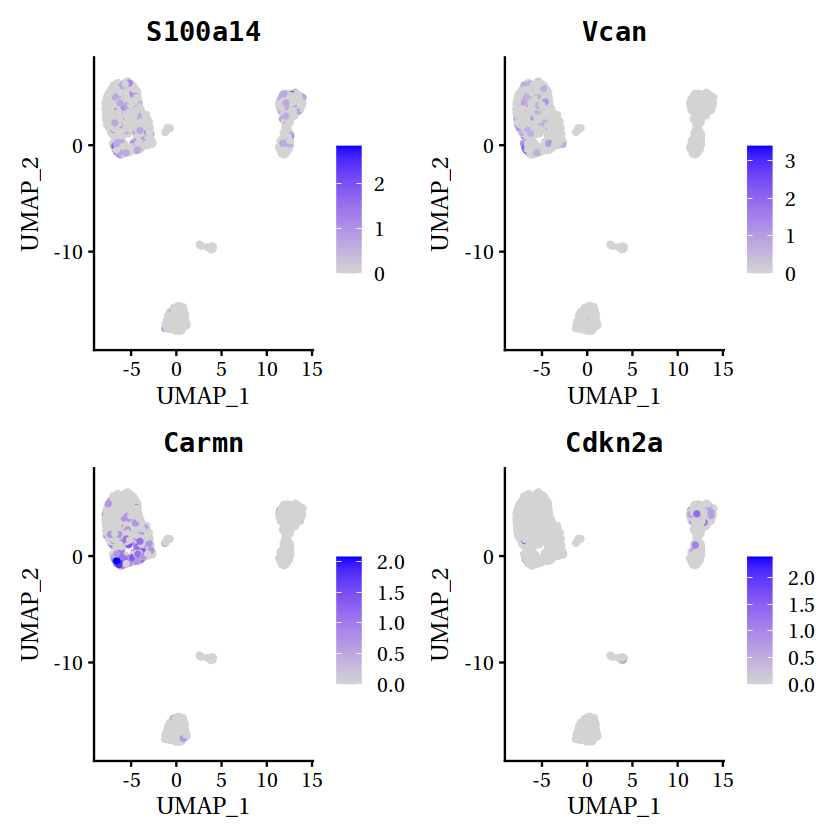

In [21]:
FeaturePlot(sub, c("S100a14","Vcan","Carmn","Cdkn2a"))

### check mut

In [22]:
sub <- subset(obj, subset = orig_ident %in% c("basal_mut","luminal_mut"))

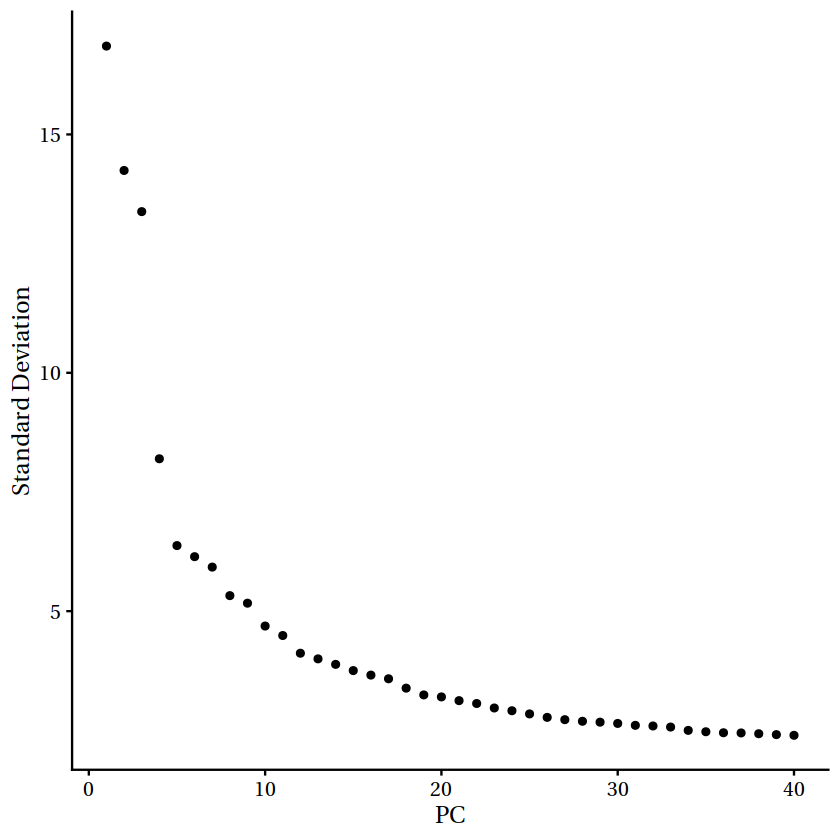

In [23]:
sub <- SCTransform(sub, residual.features = rownames(hvg), verbose = F)
sub <- RunPCA(sub, verbose = F)
ElbowPlot(sub, ndims = 40)

Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_counts_hb.”


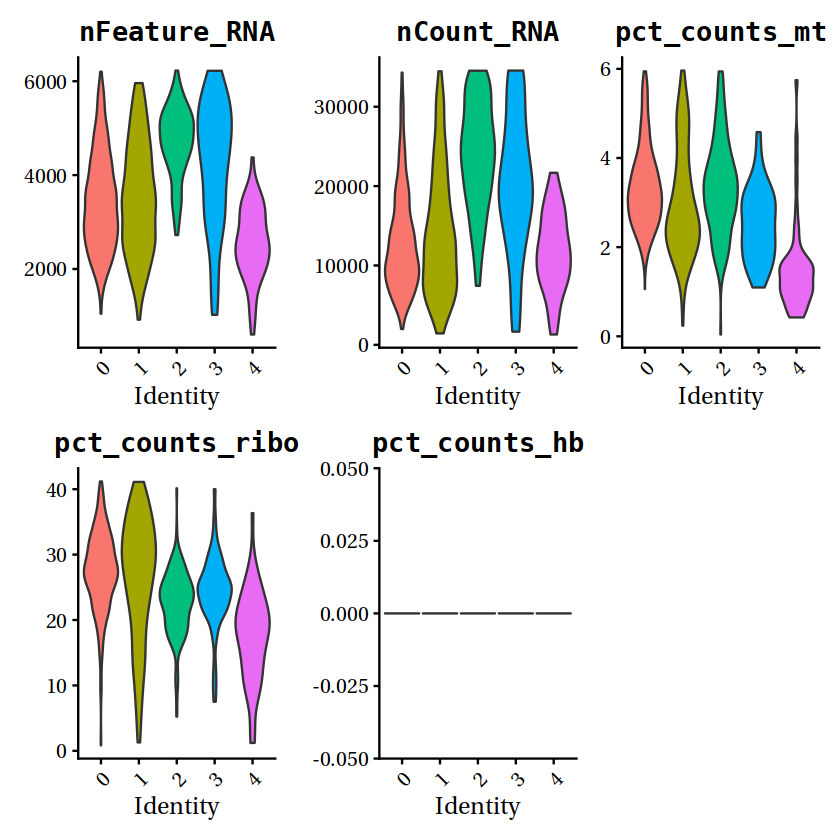

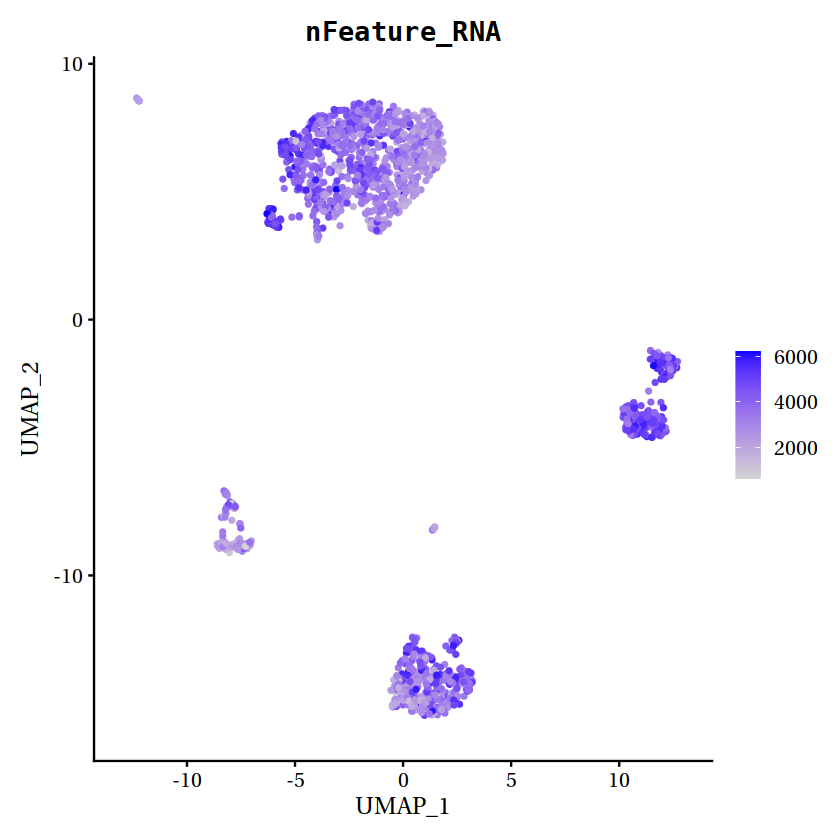

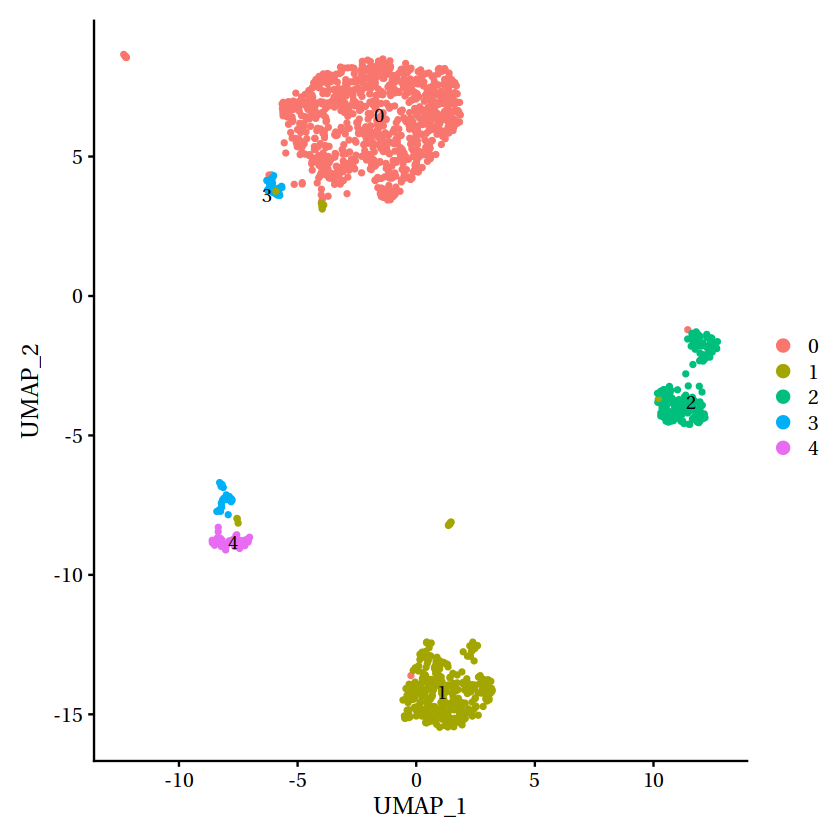

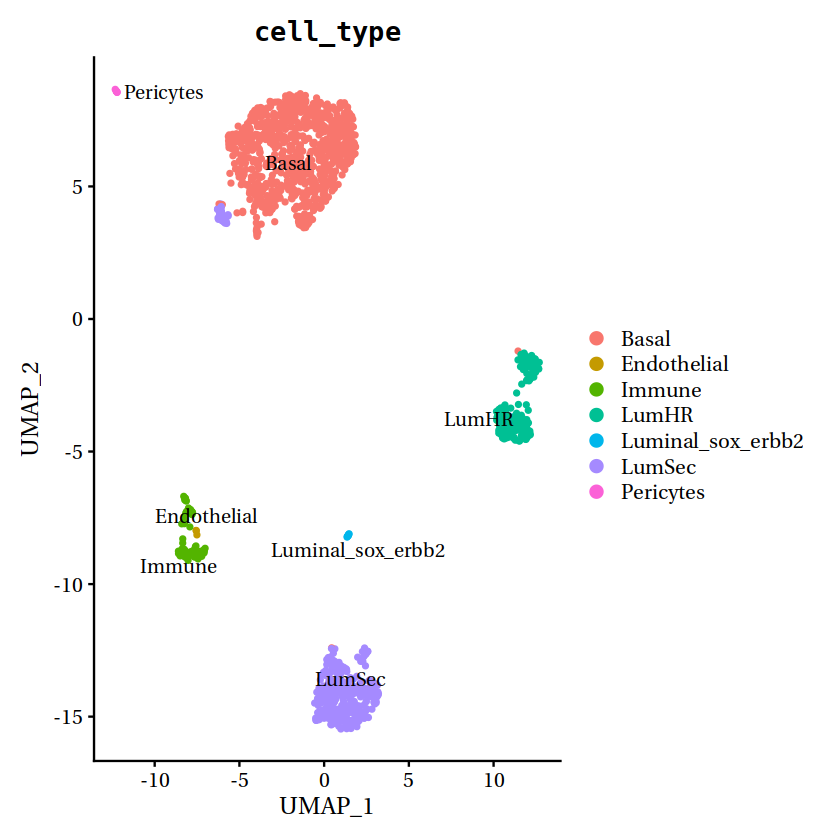

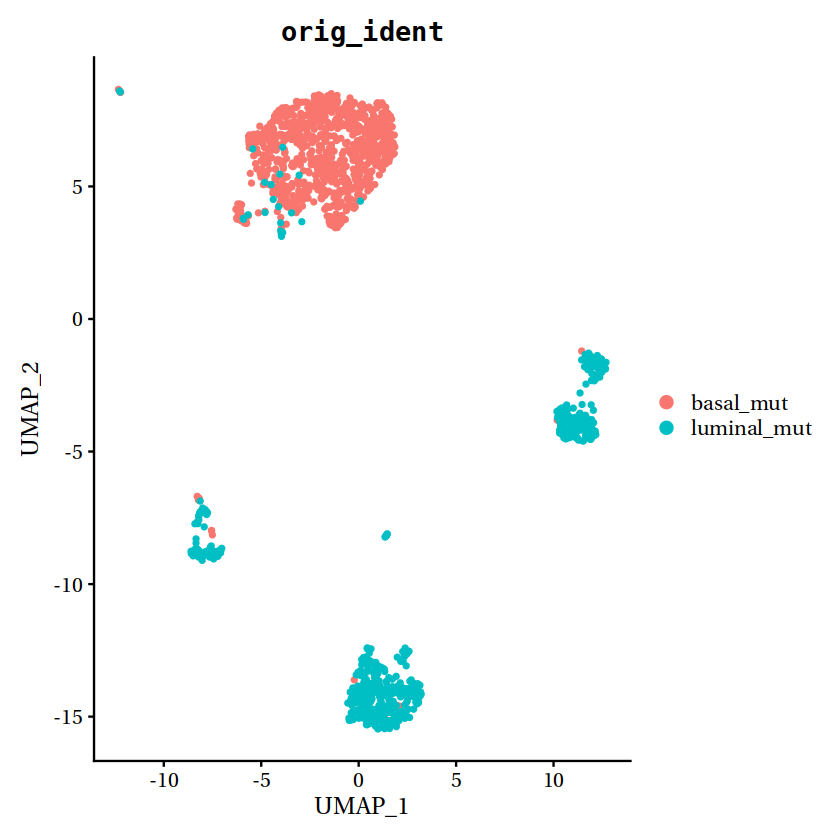

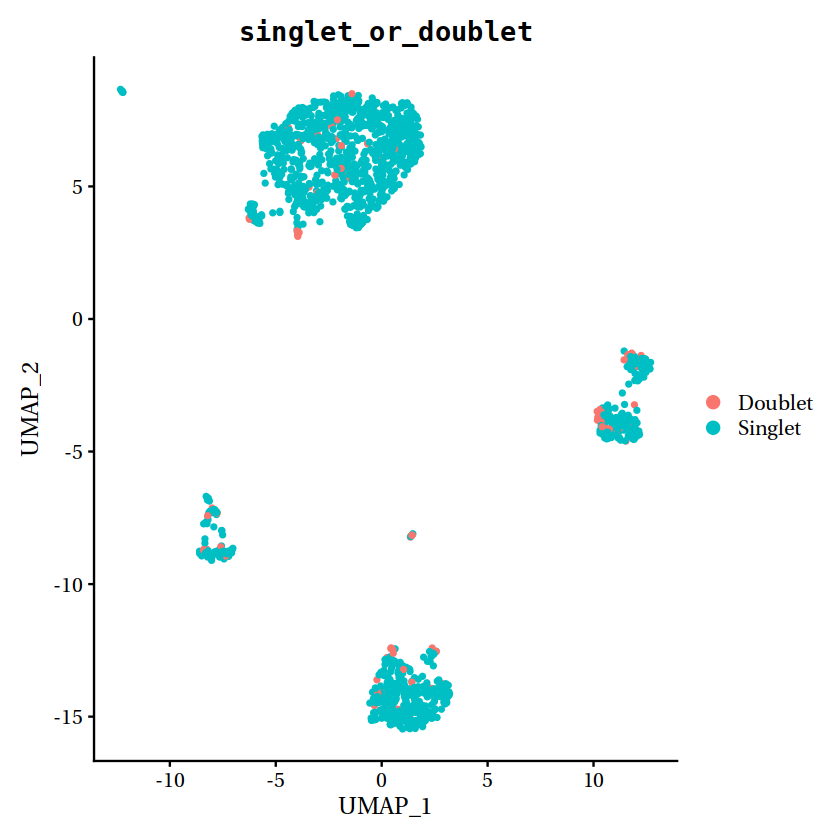

In [26]:
sub <- RunUMAP(sub, reduction = "pca", dims = 1:40, verbose = FALSE)
sub <- FindNeighbors(sub, reduction = "pca", dims = 1:40, verbose = FALSE) 
sub <- FindClusters(sub, resolution = 0.1, verbose = FALSE) 

VlnPlot(sub, features = c("nFeature_RNA", "nCount_RNA", "pct_counts_mt", 
                          "pct_counts_ribo", "pct_counts_hb"), ncol = 3, pt.size=0)
FeaturePlot(sub, features=c("nFeature_RNA"))
DimPlot(sub, reduction = "umap", label=T)
DimPlot(sub, group.by = "cell_type", label = T, repel = T)
DimPlot(sub, group.by = "orig_ident", label = F)
DimPlot(sub, group.by = "singlet_or_doublet", label = F)

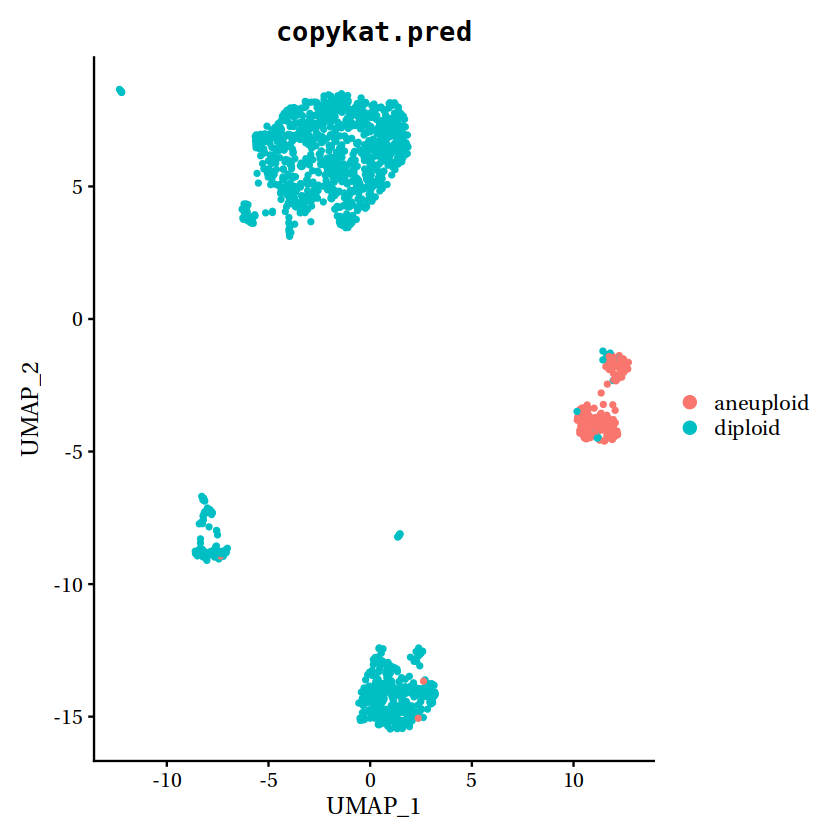

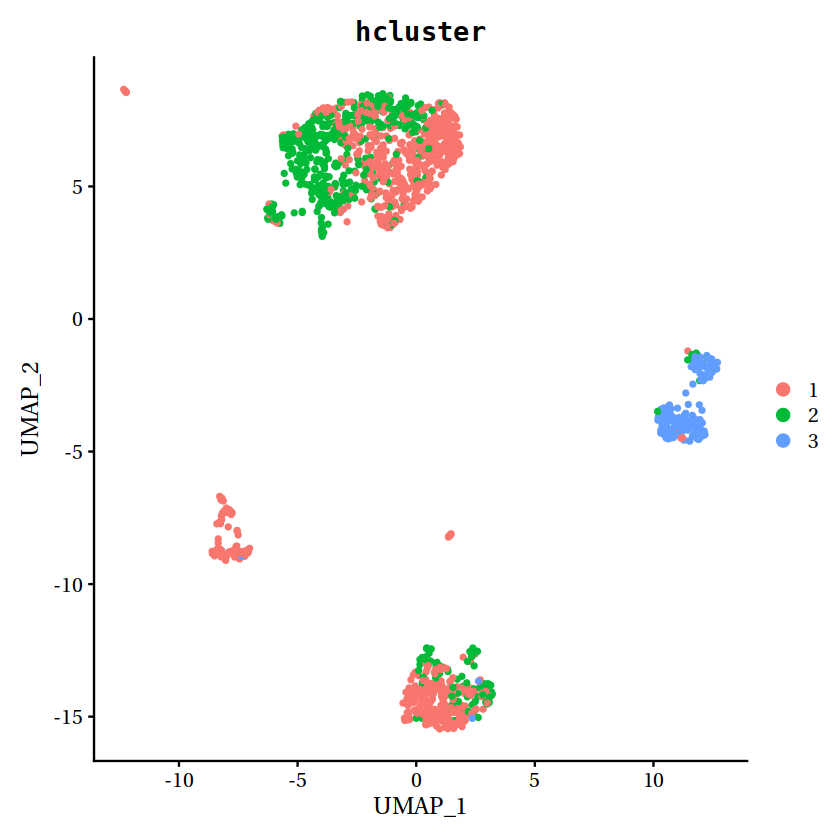

In [28]:
DimPlot(sub, group.by="copykat.pred")
DimPlot(sub, group.by="hcluster")

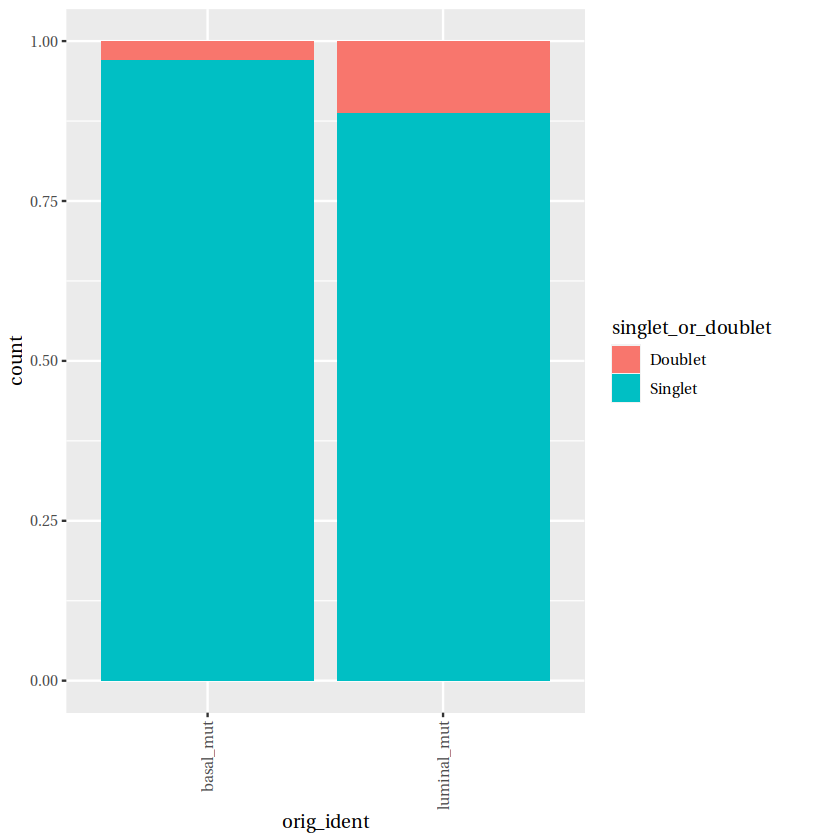

In [29]:
ggplot(sub@meta.data, aes(x=orig_ident, fill=singlet_or_doublet)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

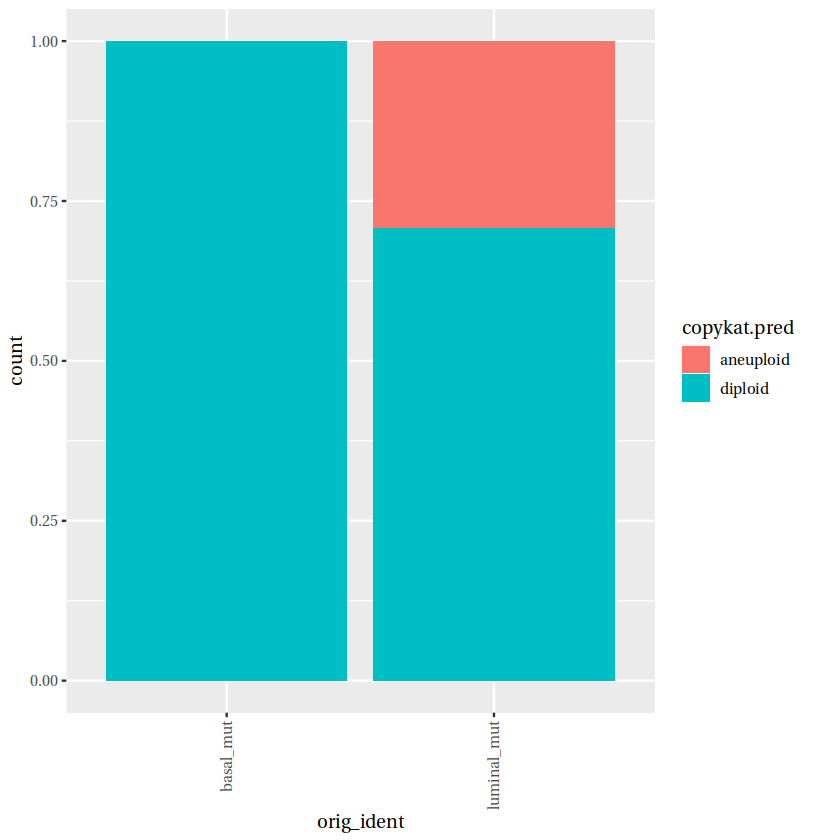

In [30]:
ggplot(sub@meta.data, aes(x=orig_ident, fill=copykat.pred)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

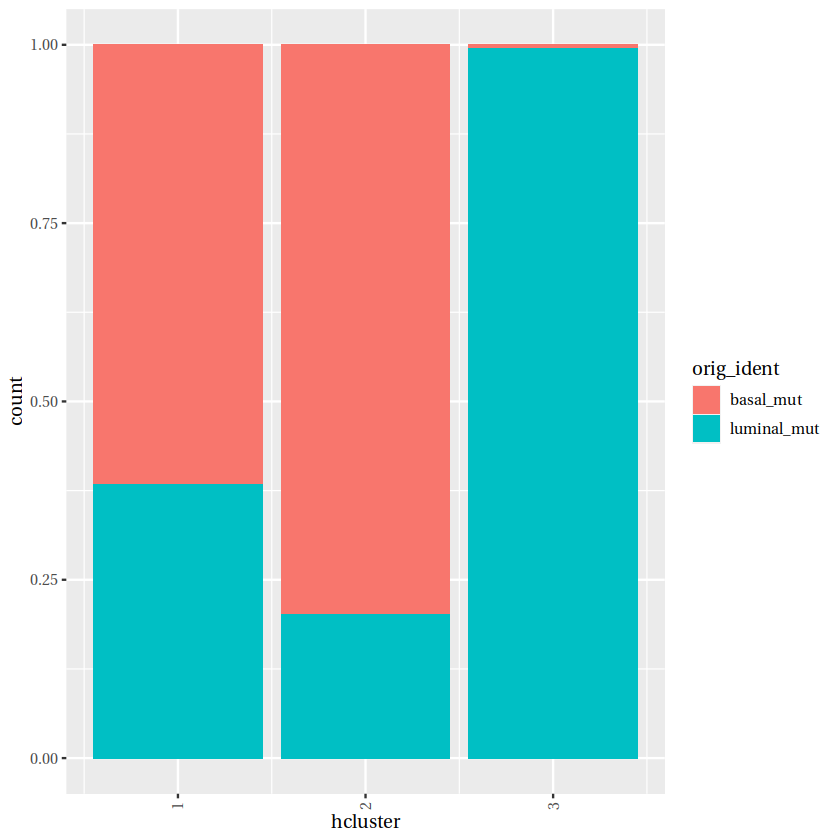

In [32]:
ggplot(sub@meta.data, aes(x=hcluster, fill=orig_ident)) + geom_bar(position = "fill") + 
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

## clean up (remove tails)

In [33]:
Idents(obj) <- "seurat_clusters"

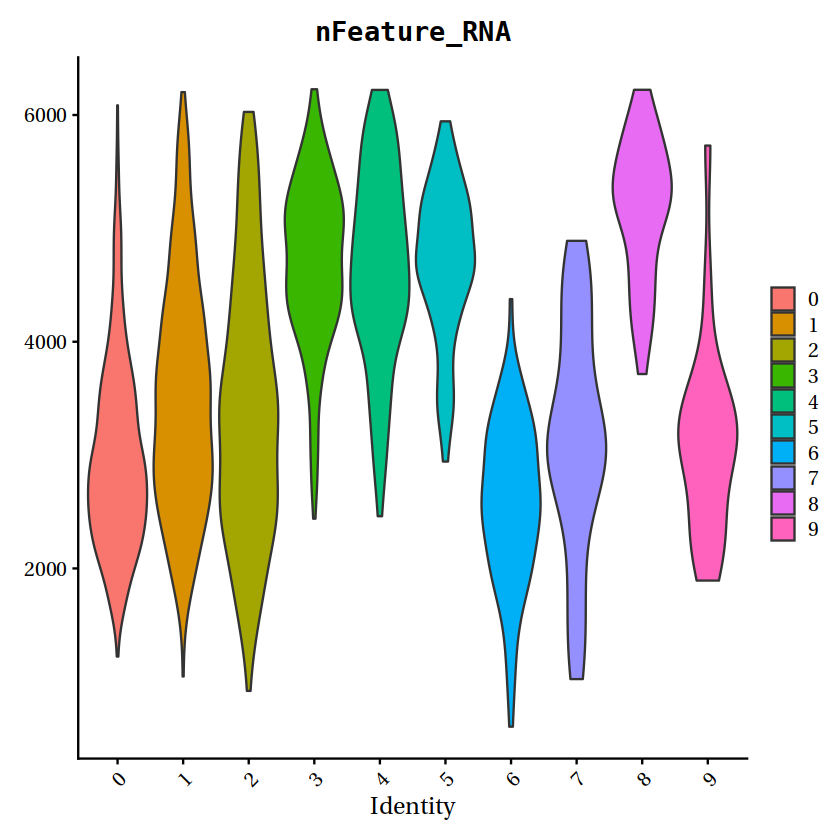

In [44]:
VlnPlot(obj, "nFeature_RNA", pt.size = 0)

Warning message in FeaturePlot(obj, c("Lum", "Rgs5", "Ptprc", "Pecam1")):
“All cells have the same value (0) of Lum.”


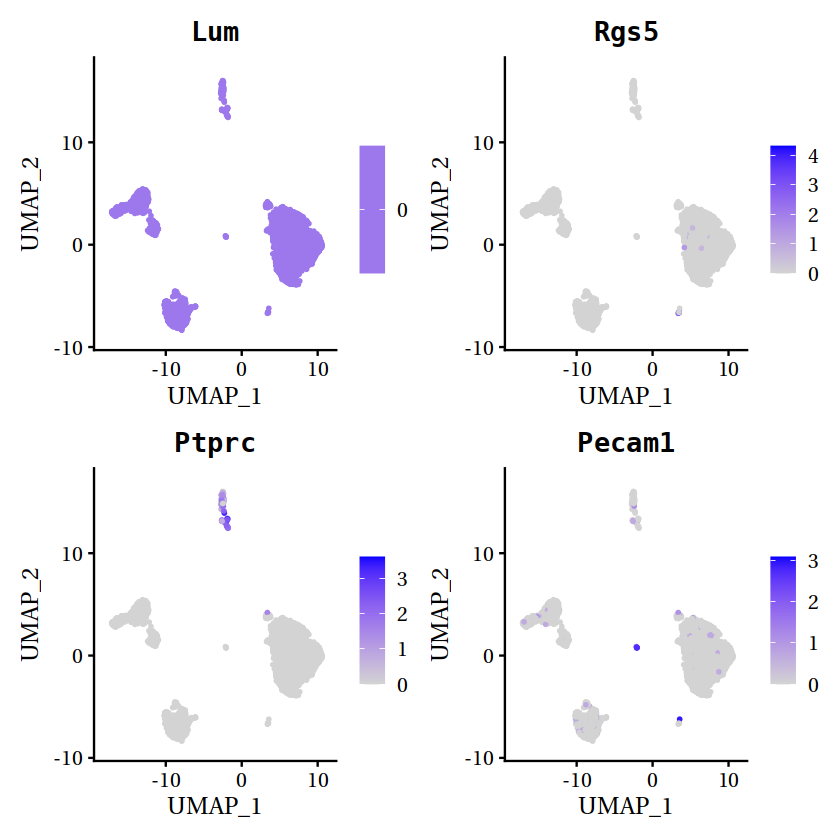

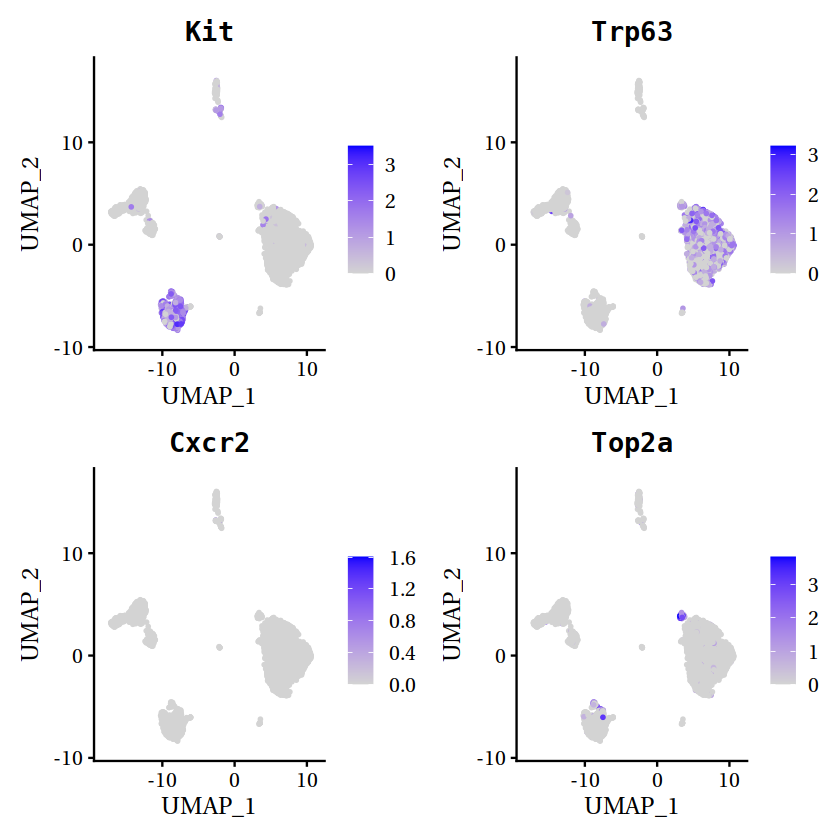

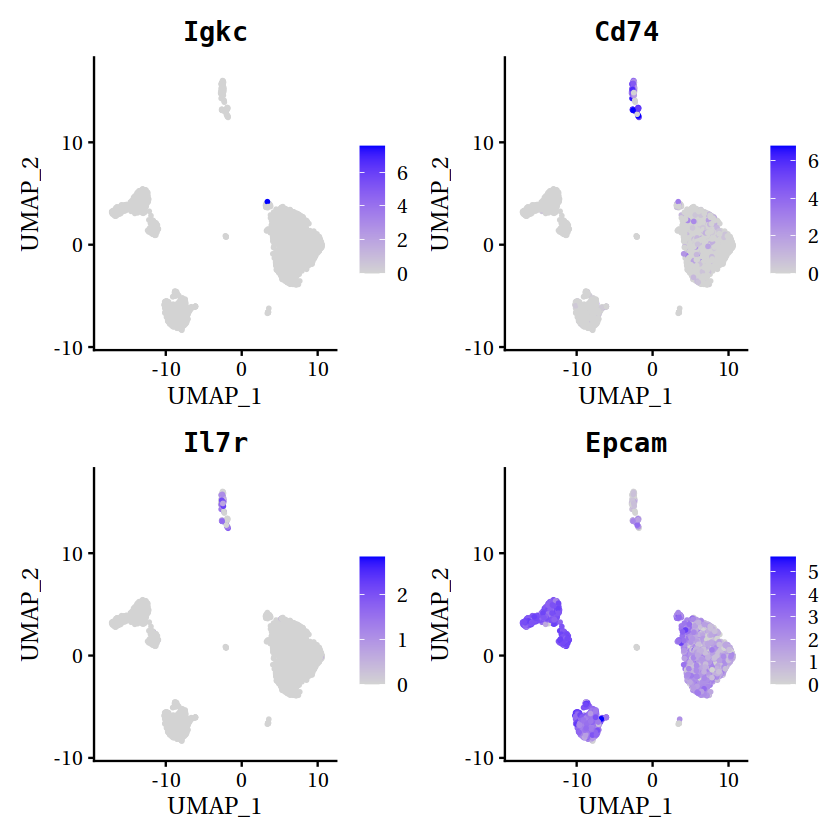

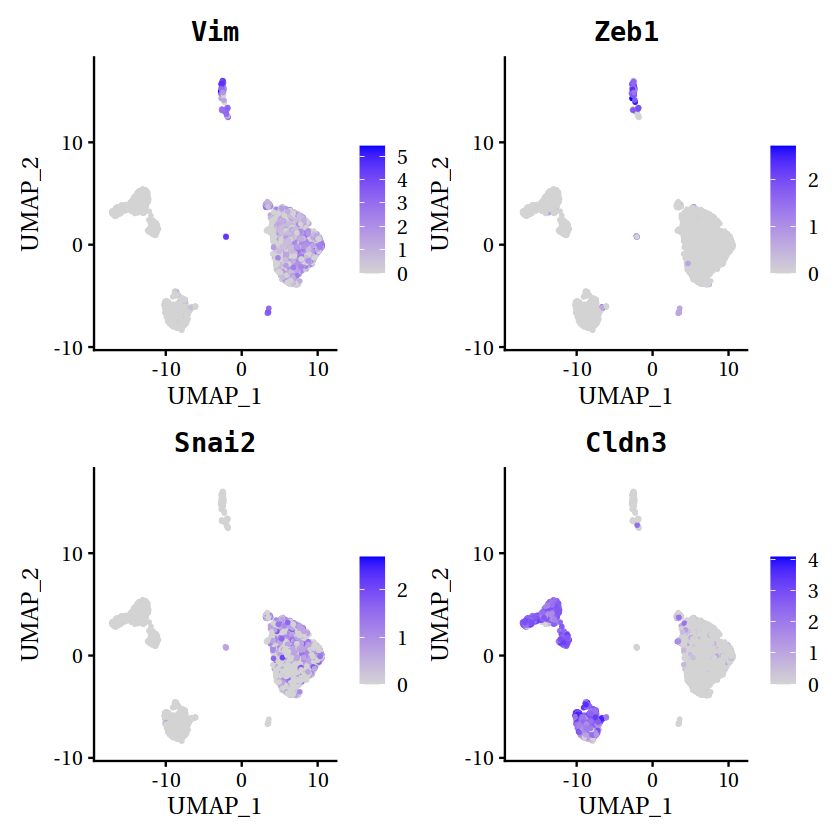

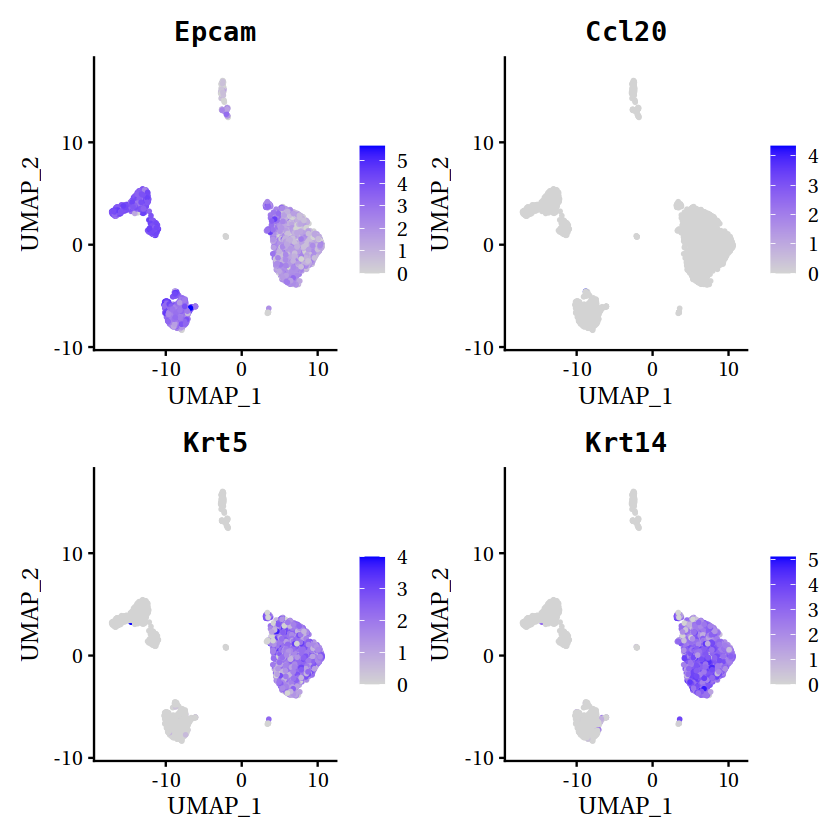

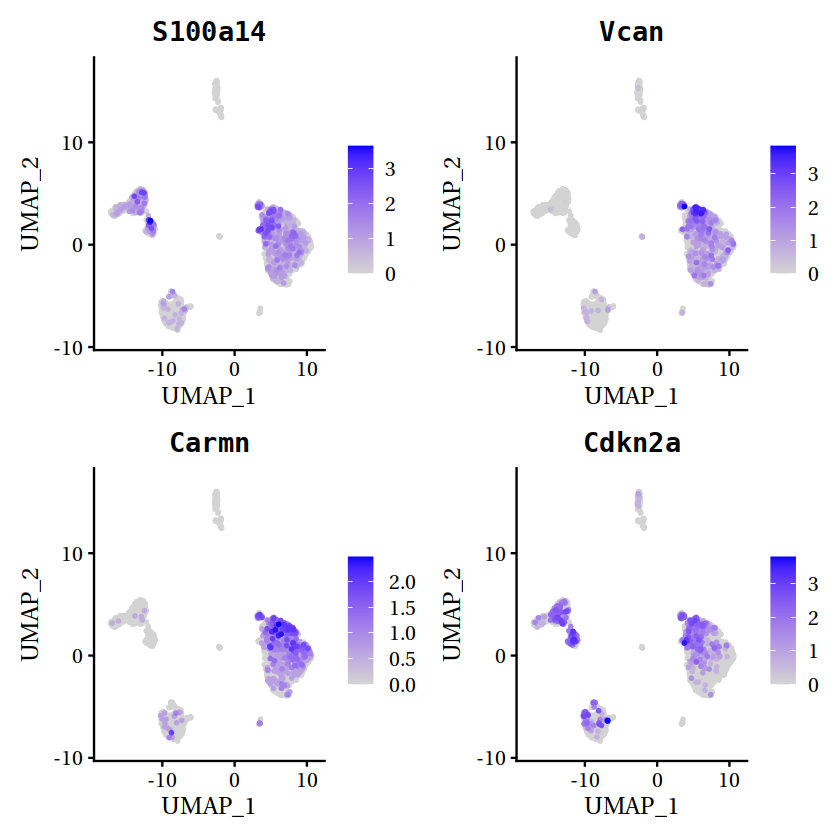

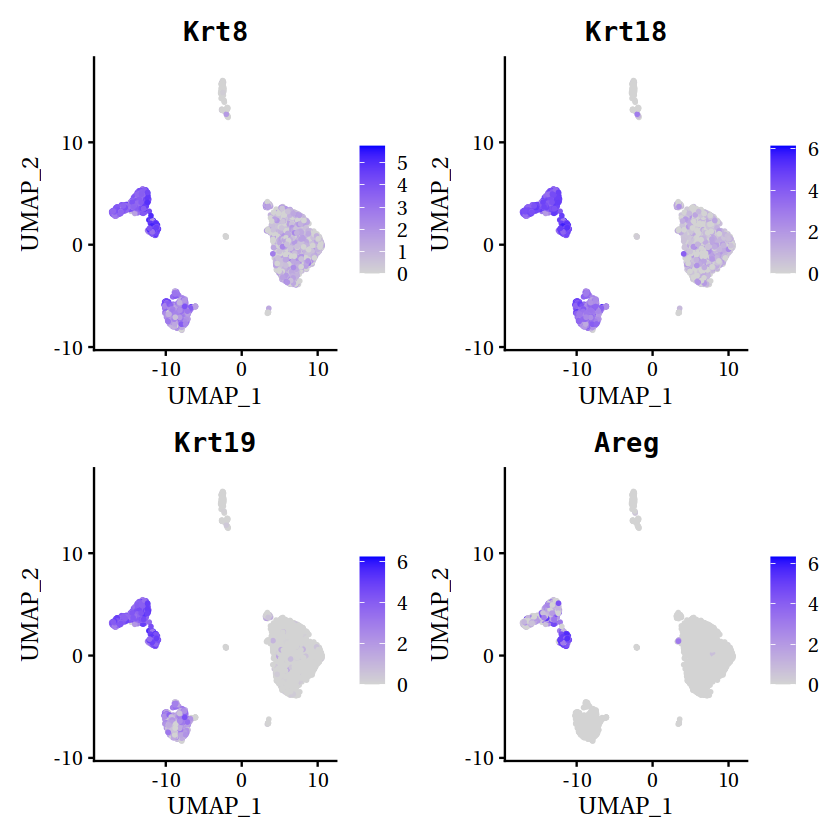

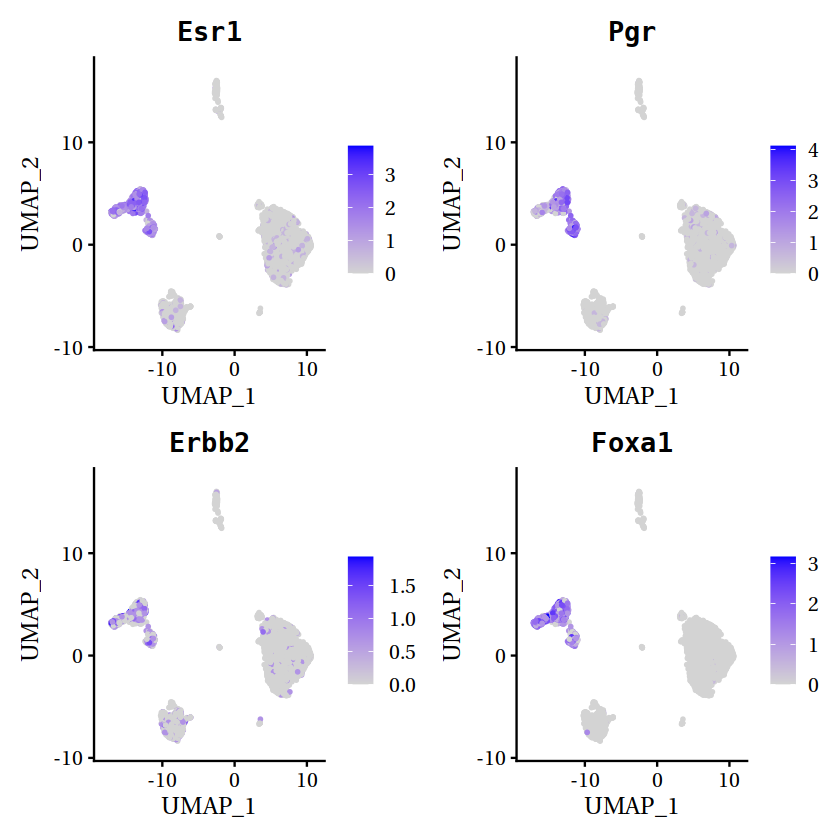

In [39]:
FeaturePlot(obj, c("Lum","Rgs5","Ptprc","Pecam1"))
FeaturePlot(obj, c("Kit","Trp63","Cxcr2","Top2a"))
FeaturePlot(obj, c("Igkc","Cd74","Il7r","Epcam"))
FeaturePlot(obj, c("Vim","Zeb1","Snai2","Cldn3"))

FeaturePlot(obj, c("Epcam","Ccl20","Krt5","Krt14"))
FeaturePlot(obj, c("S100a14","Vcan","Carmn","Cdkn2a"),order=T)
FeaturePlot(obj, c("Krt8","Krt18","Krt19","Areg"))
FeaturePlot(obj, c("Esr1","Pgr","Erbb2","Foxa1"))

### add important metadata

In [37]:
obj <- CellCycleScoring(obj, s.features = cc.genes$s.genes, 
                        g2m.features = cc.genes$g2m.genes, set.ident = FALSE)
DimPlot(obj, group.by = "Phase", shuffle = T)

Warning message:
“The following features are not present in the object: MCM5, PCNA, TYMS, FEN1, MCM2, MCM4, RRM1, UNG, GINS2, MCM6, CDCA7, DTL, PRIM1, UHRF1, MLF1IP, HELLS, RFC2, RPA2, NASP, RAD51AP1, GMNN, WDR76, SLBP, CCNE2, UBR7, POLD3, MSH2, ATAD2, RAD51, RRM2, CDC45, CDC6, EXO1, TIPIN, DSCC1, BLM, CASP8AP2, USP1, CLSPN, POLA1, CHAF1B, BRIP1, E2F8, not searching for symbol synonyms”
Warning message:
“The following features are not present in the object: HMGB2, CDK1, NUSAP1, UBE2C, BIRC5, TPX2, TOP2A, NDC80, CKS2, NUF2, CKS1B, MKI67, TMPO, CENPF, TACC3, FAM64A, SMC4, CCNB2, CKAP2L, CKAP2, AURKB, BUB1, KIF11, ANP32E, TUBB4B, GTSE1, KIF20B, HJURP, CDCA3, HN1, CDC20, TTK, CDC25C, KIF2C, RANGAP1, NCAPD2, DLGAP5, CDCA2, CDCA8, ECT2, KIF23, HMMR, AURKA, PSRC1, ANLN, LBR, CKAP5, CENPE, CTCF, NEK2, G2E3, GAS2L3, CBX5, CENPA, not searching for symbol synonyms”
Warning message in AddModuleScore(object = object, features = features, name = name, :
“Could not find enough features in the object 

ERROR: [1m[33mError[39m in [1m[1m`cut_number()`:[22m
[33m![39m Insufficient data values to produce 24 bins.


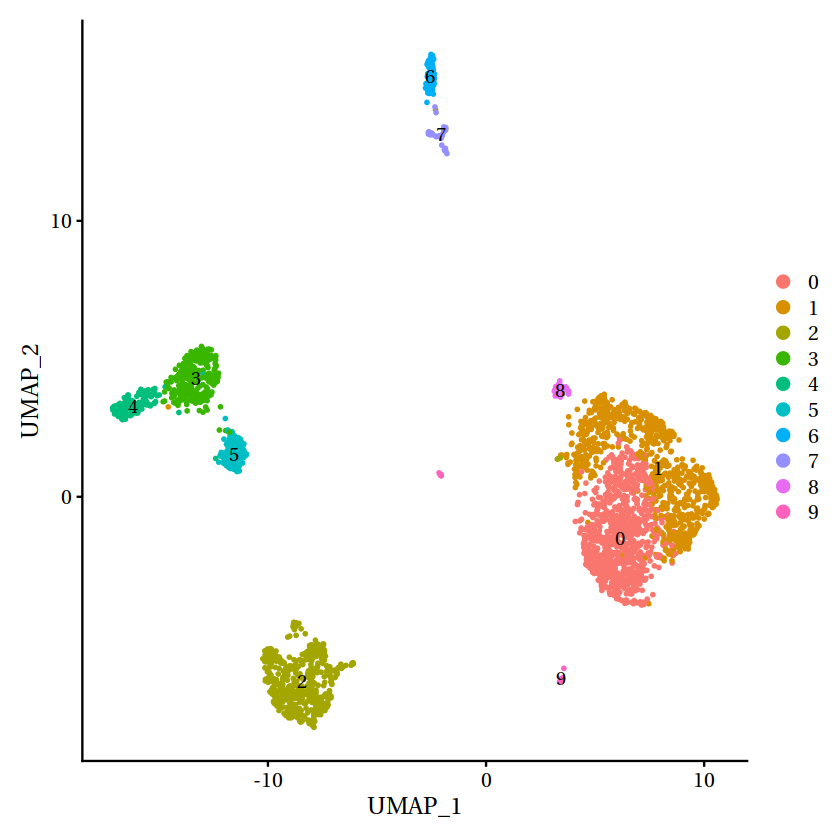

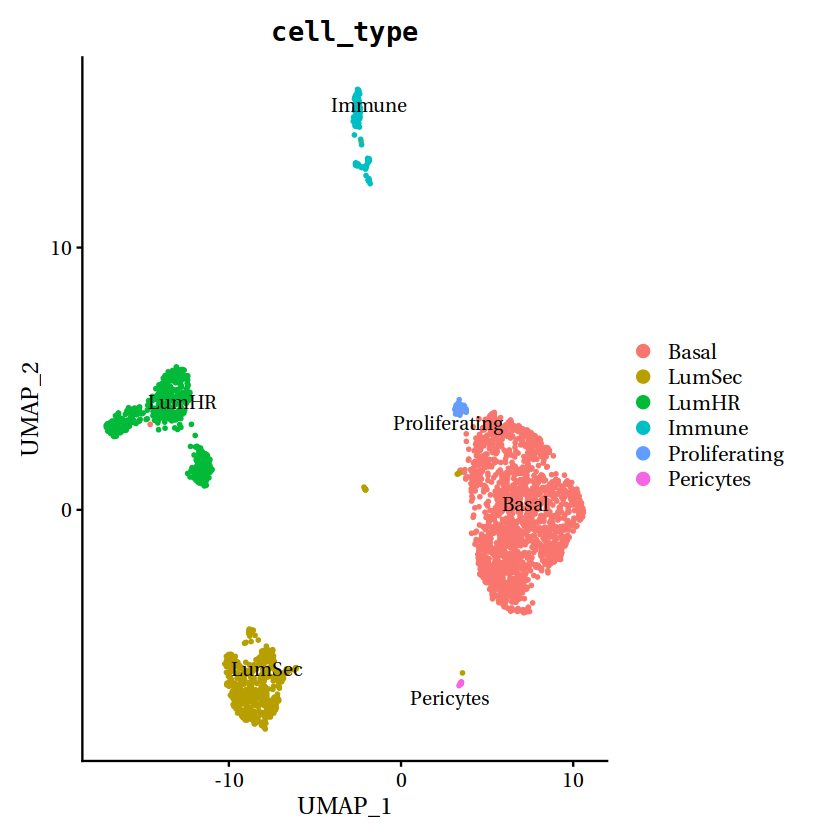

In [45]:
DimPlot(obj, reduction = "umap", label=T)
DimPlot(obj, group.by = "cell_type", label = T, repel = T)

In [46]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Basal", 
                            `1` = "Basal", 
                            `2` = "LumSec", 
                            `3` = "LumHR",
                            `4` = "LumHR",
                            `5` = "LumHR",
                            `6` = "Immune", 
                            `7` = "Immune",
                            `8` = "Proliferating", 
                            `9` = "Stromal")
obj$cell_type <- obj@active.ident

In [47]:
Idents(obj) <- "seurat_clusters"
obj <- RenameIdents(object = obj, 
                            `0` = "Epithelial", 
                            `1` = "Epithelial", 
                            `2` = "Epithelial", 
                            `3` = "Epithelial",
                            `4` = "Epithelial",
                            `5` = "Epithelial",
                            `6` = "Immune", 
                            `7` = "Immune",
                            `8` = "Epithelial", 
                            `9` = "Stromal")
obj$cell_type_group <- obj@active.ident

In [48]:
table(obj$orig_ident)


  basal_mut    basal_wt luminal_mut  luminal_wt 
        932         798         602         539 

In [50]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `basal_mut` = "mutant", 
                            `basal_wt` = "wildtype", 
                            `luminal_mut` = "mutant",
                            `luminal_wt` = "wildtype")
obj$genotype <- obj@active.ident

In [51]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `basal_mut` = "mutant", 
                            `basal_wt` = "normal", 
                            `luminal_mut` = "mutant",
                            `luminal_wt` = "normal")
obj$condition_metastatic_burden <- obj@active.ident

In [52]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `basal_mut` = "mutant", 
                            `basal_wt` = "normal", 
                            `luminal_mut` = "mutant",
                            `luminal_wt` = "normal")
obj$condition_tumor_size_mm <- obj@active.ident

In [54]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `basal_mut` = "mutant", 
                            `basal_wt` = "normal", 
                            `luminal_mut` = "mutant",
                            `luminal_wt` = "normal")
obj$condition <- obj@active.ident

In [47]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `basal_mut` = "mammary", 
                            `basal_wt` = "mammary", 
                            `luminal_mut` = "mammary",
                            `luminal_wt` = "mammary")
obj$organ <- obj@active.ident

In [55]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `basal_mut` = "original", 
                            `basal_wt` = "original", 
                            `luminal_mut` = "original",
                            `luminal_wt` = "original")
obj$transplant_status <- obj@active.ident

In [56]:
obj$cellplex <- "8"
obj$sc_assay <- "cellplex_GEX_v3.1"

In [58]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `basal_mut` = "removed", 
                            `basal_wt` = "removed", 
                            `luminal_mut` = "removed",
                            `luminal_wt` = "removed")
obj$lymph_node_presence <- obj@active.ident

In [59]:
Idents(obj) <- "orig_ident"
obj <- RenameIdents(object = obj,
                            `basal_mut` = "mutant_four_pooled", 
                            `basal_wt` = "wildtype_two_pooled", 
                            `luminal_mut` = "mutant_four_pooled",
                            `luminal_wt` = "wildtype_two_pooled")
obj$mouse <- obj@active.ident

In [60]:
as.data.frame(colnames(obj[[]]))

colnames(obj[[]])
<chr>
orig.ident
nCount_RNA
nFeature_RNA
orig_ident
pct_counts_mt
pct_counts_ribo
pct_counts_hb
leiden_res_0.10
cell_type


In [62]:
#obj$S.Score <- NULL
#obj$G2M.Score <- NULL
obj$SCT_snn_res.0.2 <- NULL
obj$SCT_snn_res.0.3 <- NULL

In [63]:
meta <- read.csv("cellplex8.adata.obs.metadata.csv", row.names=1)
obj <- AddMetaData(obj, meta['cell_type'], "orig_cell_type")

In [64]:
saveRDS(obj, "cellplex8_soupX_doubletfinder_cnv_metadata.rds")